<a href="https://colab.research.google.com/github/zeynepbykn/SMS_Spam_Tespiti_Proje/blob/main/SMS_spam_veriBilimi_proje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Veriyi Okuma ve İstatistikleri **Çıkarma**

In [ ]:
import pandas as pd #veri analizi
import matplotlib.pyplot as plt #veri gorsellestirme
import seaborn as sns
#veriyi internetten cekmek icin
import zipfile
import requests
import io

# Veriyi doğrudan UCI sitesinden indiriyoruz
url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
response = requests.get(url)

# İndirilen zip içeriğini açıyoruz
with zipfile.ZipFile(io.BytesIO(response.content), 'r') as zip_ref:
    zip_ref.extractall('sms_data') # 'sms_data' isimli bir klasöre çıkartır

# Veriyi DataFrame'e donusturme
df = pd.read_csv('sms_data/SMSSpamCollection', sep='\t', names=['label', 'message'])
#label -> mesajın ham(0) yada spam(1) oldugunu belirtir

print("Veri Seti Boyutu:", df.shape) # (5574, 2):5574 mesaj ve 2 sütun
## df.head(): Tablonun en üstündeki ilk 5 satırı ekrana getirir.
print("\nİlk 5 Satır:\n", df.head())

# Sınıf Dağılımı
# label sütunundaki değerleri sayar:kaç tane ham,spam mesaj oldugunu yazdırır.
print("\nSınıf Sayıları:")
print(df['label'].value_counts())

Veri Seti Boyutu: (5572, 2)

İlk 5 Satır:
   label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Sınıf Sayıları:
label
ham     4825
spam     747
Name: count, dtype: int64


Görselleştirme (Grafik) **Kodları**

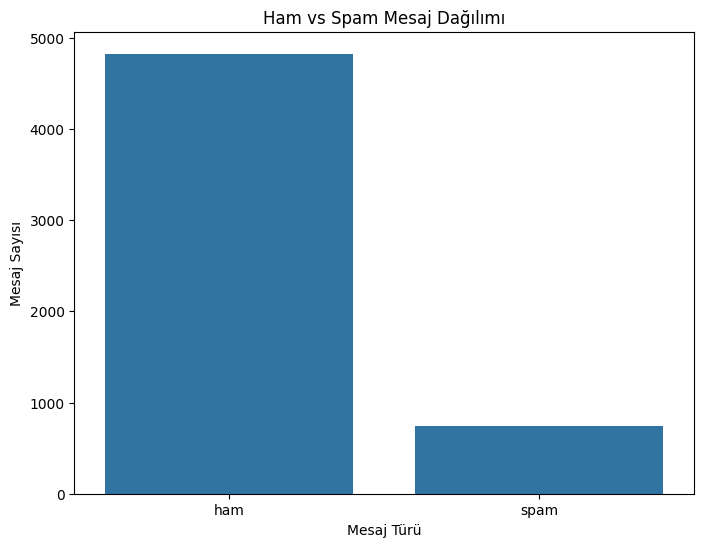

In [ ]:
# Grafiğin boyutu: (8 birim genişlik, 6 birim yükseklik).
plt.figure(figsize=(8,6))

# sns.countplot: Kategorik veriler için (ham/spam) sütun grafiği çizer.
# x='label': Alt eksende etiketler (ham ve spam) yer alacak.
sns.countplot(x='label', data=df)

# Grafiğe başlık ve eksen isimleri ekliyoruz.
plt.title('Ham vs Spam Mesaj Dağılımı') # Grafiğin ana başlığı.
plt.xlabel('Mesaj Türü') # Yatay eksen ismi.
plt.ylabel('Mesaj Sayısı') # Dikey eksen ismi.

# plt.show ile grafiği çizer
plt.show()

# Veri Temizliği(NLP Preprocessing)

In [ ]:
import string
import nltk
from nltk.corpus import stopwords

# Gerekli paketleri indiriyoruz
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def temizle(metin):
    metin = metin.lower() # Hepsini kucuk harfe çevirir.
    metin = ''.join([char for char in metin if char not in string.punctuation]) # Noktalama işaretlerini kaldırır.
    metin = ''.join([char for char in metin if not char.isdigit()]) # Sayıları kaldırır.
    metin = ' '.join([kelime for kelime in metin.split() if kelime not in stop_words]) # Stopwords(the,is,and..)
    return metin

# Temizlemeden önce orijinal uzunluğu ölçelim
df['mesaj_uzunluk'] = df['message'].apply(len)
#spam mesajlar genelde daha uzundur.

# Temizleme işlemini uygulayalım
df['temiz_mesaj'] = df['message'].apply(temizle)

print("Temizleme işlemi tamamlandı!")
print("\n--- Makale İçin Ön Analiz ---")
# Spam ve Ham mesajların uzunluk farkını görelim
print(df.groupby('label')['mesaj_uzunluk'].mean())

Temizleme işlemi tamamlandı!

--- Makale İçin Ön Analiz ---
label
ham      71.482487
spam    138.670683
Name: mesaj_uzunluk, dtype: float64


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Metin temizleme aşamasında:
- NLTK kütüphanesi (stopwords) kullanılarak, sınıflandırma üzerinde etkisi ve anlamı olmayan ve sık tekrar eden kelimeler veri setinden arındırılmıştır. (the,and,is...)
Bu sayede modelin boyutu küçülür ve 'free', 'win', 'call' gibi ayırt edici kelimelerin frekansı (TF-IDF ağırlığı) daha anlamlı hale getirilir.


# TF-IDF (Kelime Ağırlıgı Hesaplama)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF nesnesini oluşturuyoruz
# max_features=3000: En önemli 3000 kelimeyi alıyoruz(tum kelimeleri alırsak gurultu katabilir,modelin kafası karışabilir)
tfidf = TfidfVectorizer(max_features=3000)

# Temizlenmiş mesajlarımızı sayılara dönüştürüyoruz(Çunku model sayılardan anlıyor.)
X = tfidf.fit_transform(df['temiz_mesaj']).toarray()

# Hedef değişkenimizi (spam mi ham mi) sayısallaştırıyoruz
# ham = 0, spam = 1
y = df['label'].map({'ham': 0, 'spam': 1}).values

print("Vektörleştirme Tamamlandı!")
print("X (Girdi) Boyutu:", X.shape) # (5572, 3000) gibi bir sonuç gelmeli

Vektörleştirme Tamamlandı!
X (Girdi) Boyutu: (5572, 3000)


TF-IDF ile mesajlarımızdaki kelimeleri sayısal vektöre dönüştürüyoruz modelin anlaması için.
-TF (Kelime Sıklığı):Mesajda kelimenin ne kadar gectigine bakar

-IDF(Ters Belge Sıklığı):Mesajdaki kelimenin tğm verşsetşndeki oranına bakarak nadirliğine bakar.

Sonuc olarak her mesajdaki kelimenin ağırlığı TF*IDF çarpılarak hesaplanır.

# Eğitim ve Test Olarak Bölme

In [ ]:
from sklearn.model_selection import train_test_split

# Verinin %20'sini test (sınav), %80'ini eğitim için ayırıyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Eğitim seti (X_train) boyutu:", X_train.shape)
print("Test seti (X_test) boyutu:", X_test.shape)

Eğitim seti (X_train) boyutu: (4457, 3000)
Test seti (X_test) boyutu: (1115, 3000)


# DECİSİON **TREE**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Modeli Tanımlama
# max_depth=5: Ağacın çok karmaşıklaşmasını ve ezberlemesini önlemek için
# maksimum derinliği 5 ile sınırlıyoruz.
# random_state=42: Deneyi her çalıştırdığımızda aynı sonuçları almamızı sağlar.
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# Modeli Eğitme
# Model, X_train'deki kelime ağırlıklarına bakarak hangi kelimenin
# spama, hangisinin hama çektiğini (kuralları) öğrenir.
dt_model.fit(X_train, y_train)

# Tahmin Yapma
# Test setindeki (X_test) mesajları kendi oluşturduğu Evet/Hayır
# sorularından geçirir.
y_pred_dt = dt_model.predict(X_test)

# Sonuçları Yazdırma
print("--- Karar Ağacı Performans Sonuçları ---")
# Modelin tahminleri (y_pred_dt) ile gerçek cevapları (y_test) karşılaştırır.
print(f"Doğruluk (Accuracy) Skoru: %{accuracy_score(y_test, y_pred_dt)*100:.2f}")
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred_dt))

--- Karar Ağacı Performans Sonuçları ---
Doğruluk (Accuracy) Skoru: %94.53

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       966
           1       0.94      0.63      0.76       149

    accuracy                           0.95      1115
   macro avg       0.94      0.81      0.86      1115
weighted avg       0.95      0.95      0.94      1115



Karar Ağacı modelimiz %94.53 genel doğruluk oranına sahip olması veri setimizin dengesiz olmasından kaynaklanıyor.Model, ham mesajları neredeyse tamamını doğru bildiği için genel skor yükseliyor fakat spam mesajlarını kaçırıyor.

Recall genel %81 çünkü spam örnekleri sayıca az olduğu için ağaç,spam sınıfının tüm varyasyonlarını öğrenecek kadar derinleşemiyor ve yeterli dal bulamıyor olabilir.

# Öznitelik Önem **Grafiği**

/tmp/ipykernel_6910/2900202912.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Onem', y='Kelime', data=feature_importance_df, palette='viridis')


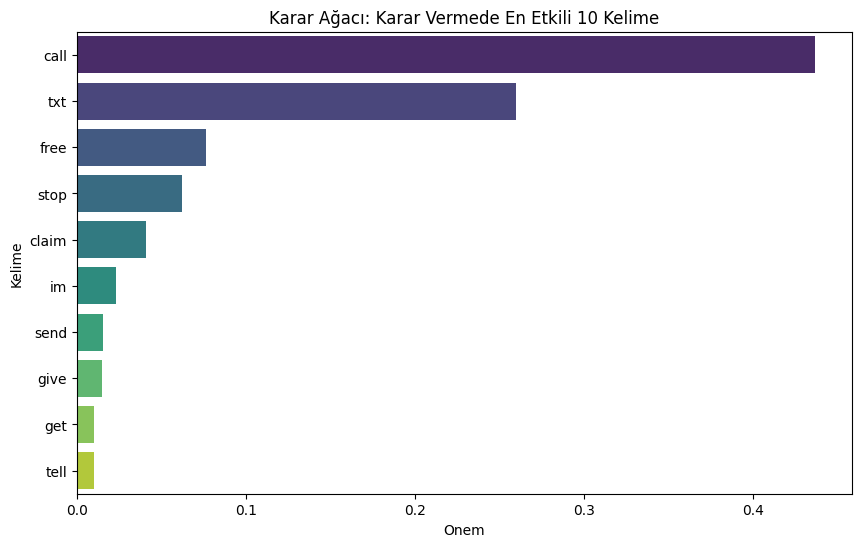

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Öznitelik önemlerini alalım
importances = dt_model.feature_importances_
feature_names = tfidf.get_feature_names_out()

# Veriyi tablo haline getirelim
feature_importance_df = pd.DataFrame({'Kelime': feature_names, 'Onem': importances})
feature_importance_df = feature_importance_df.sort_values(by='Onem', ascending=False).head(10)

# Çizim
plt.figure(figsize=(10, 6))
sns.barplot(x='Onem', y='Kelime', data=feature_importance_df, palette='viridis')
plt.title('Karar Ağacı: Karar Vermede En Etkili 10 Kelime')
plt.show()

Öznitelik Önem Grafiği (Feature Importance)
Bu grafik, modelin bir mesajın Spam mi yoksa Ham mi olduğuna karar verirken "en çok hangi kelimelere güvendiğini" gösterir:

Ayırt Edici Kelimeler: 'free', 'win', 'claim' gibi kelimelerin model üzerindeki etkisi matematiksel olarak en yüksektir.

Bilgi Kazancı: Grafikteki yüksek çubuklar, o kelimenin spam tespitinde en çok "bilgi kazancı" (Information Gain) sağlayan öznitelik olduğunu kanıtlar.

Model Şeffaflığı: Modelin karar verme mantığını görselleştirerek, hangi kelimelerin sınıflandırma başarısını doğrudan artırdığını ortaya koyar.

# **Karmaşıklık Matrisi ve Başarı Metrikleri**

/tmp/ipykernel_6910/575556457.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette=colors, ax=ax2)


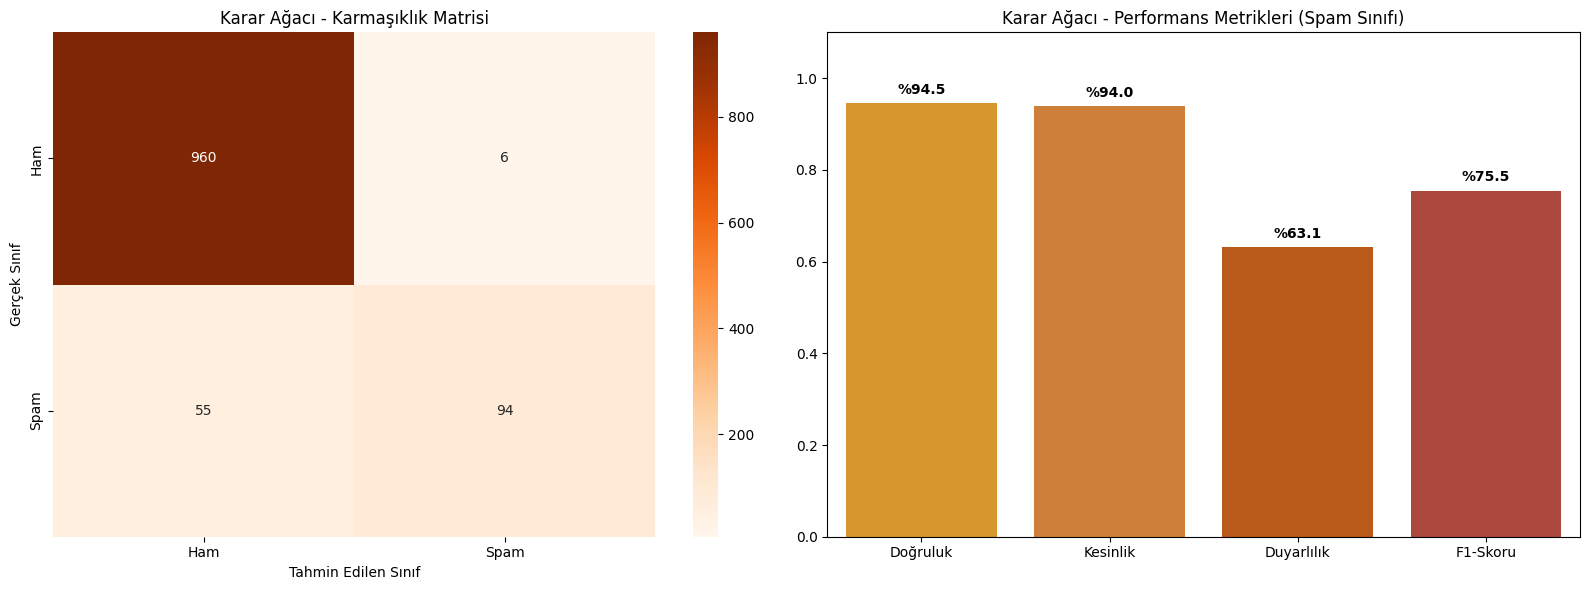

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# Tahminleri alıyoruz
y_pred_dt = dt_model.predict(X_test)

# Metrikler hesaplanır (Spam sınıfı için)
accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt)
recall = recall_score(y_test, y_pred_dt)
f1 = f1_score(y_test, y_pred_dt)

# Görselleştirme (Yan yana iki grafik)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- SOL TARAF: Karmaşıklık Matrisi ---
cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax1,
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
ax1.set_title('Karar Ağacı - Karmaşıklık Matrisi')
ax1.set_xlabel('Tahmin Edilen Sınıf')
ax1.set_ylabel('Gerçek Sınıf')

# --- SAĞ TARAF: Başarı Metrikleri ---
metrics = ['Doğruluk', 'Kesinlik', 'Duyarlılık', 'F1-Skoru']
values = [accuracy, precision, recall, f1]
colors = ['#f39c12', '#e67e22', '#d35400', '#c0392b']

sns.barplot(x=metrics, y=values, palette=colors, ax=ax2)
ax2.set_ylim(0, 1.1)
ax2.set_title('Karar Ağacı - Performans Metrikleri (Spam Sınıfı)')

# Çubukların üzerine değerleri yazdıralım
for i, v in enumerate(values):
    ax2.text(i, v + 0.02, f"%{v*100:.1f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Bu grafikler, Karar Ağacı (Decision Tree) modelinin Spam ve Ham mesajları ayırmadaki başarısını detaylandırır:

Karmaşıklık Matrisi (Confusion Matrix): Modelin gerçek sınıflar ile tahminleri arasındaki ilişkiyi gösterir. Örneğin; 960 mesaj doğru şekilde "Ham" olarak, 94 mesaj ise doğru şekilde "Spam" olarak yakalanmıştır.

Duyarlılık (Recall) Başarısı: %63.1 olan duyarlılık oranı, veri setindeki sınıfsal dengesizliğin (ham mesajların spam mesajlara üstünlüğü) model üzerindeki etkisini gösterir; model gerçek spam'lerin bir kısmını kaçırmaktadır.

F1-Skoru: Kesinlik ve duyarlılığın harmonik ortalaması olan %75.5 değeri, modelin spam sınıfı üzerindeki genel performans dengesini ifade eder.

Hata Analizi: Sol alttaki 55 rakamı, spam olduğu halde "Ham" olarak tahmin edilen (kaçıran) mesaj sayısını temsil eder.

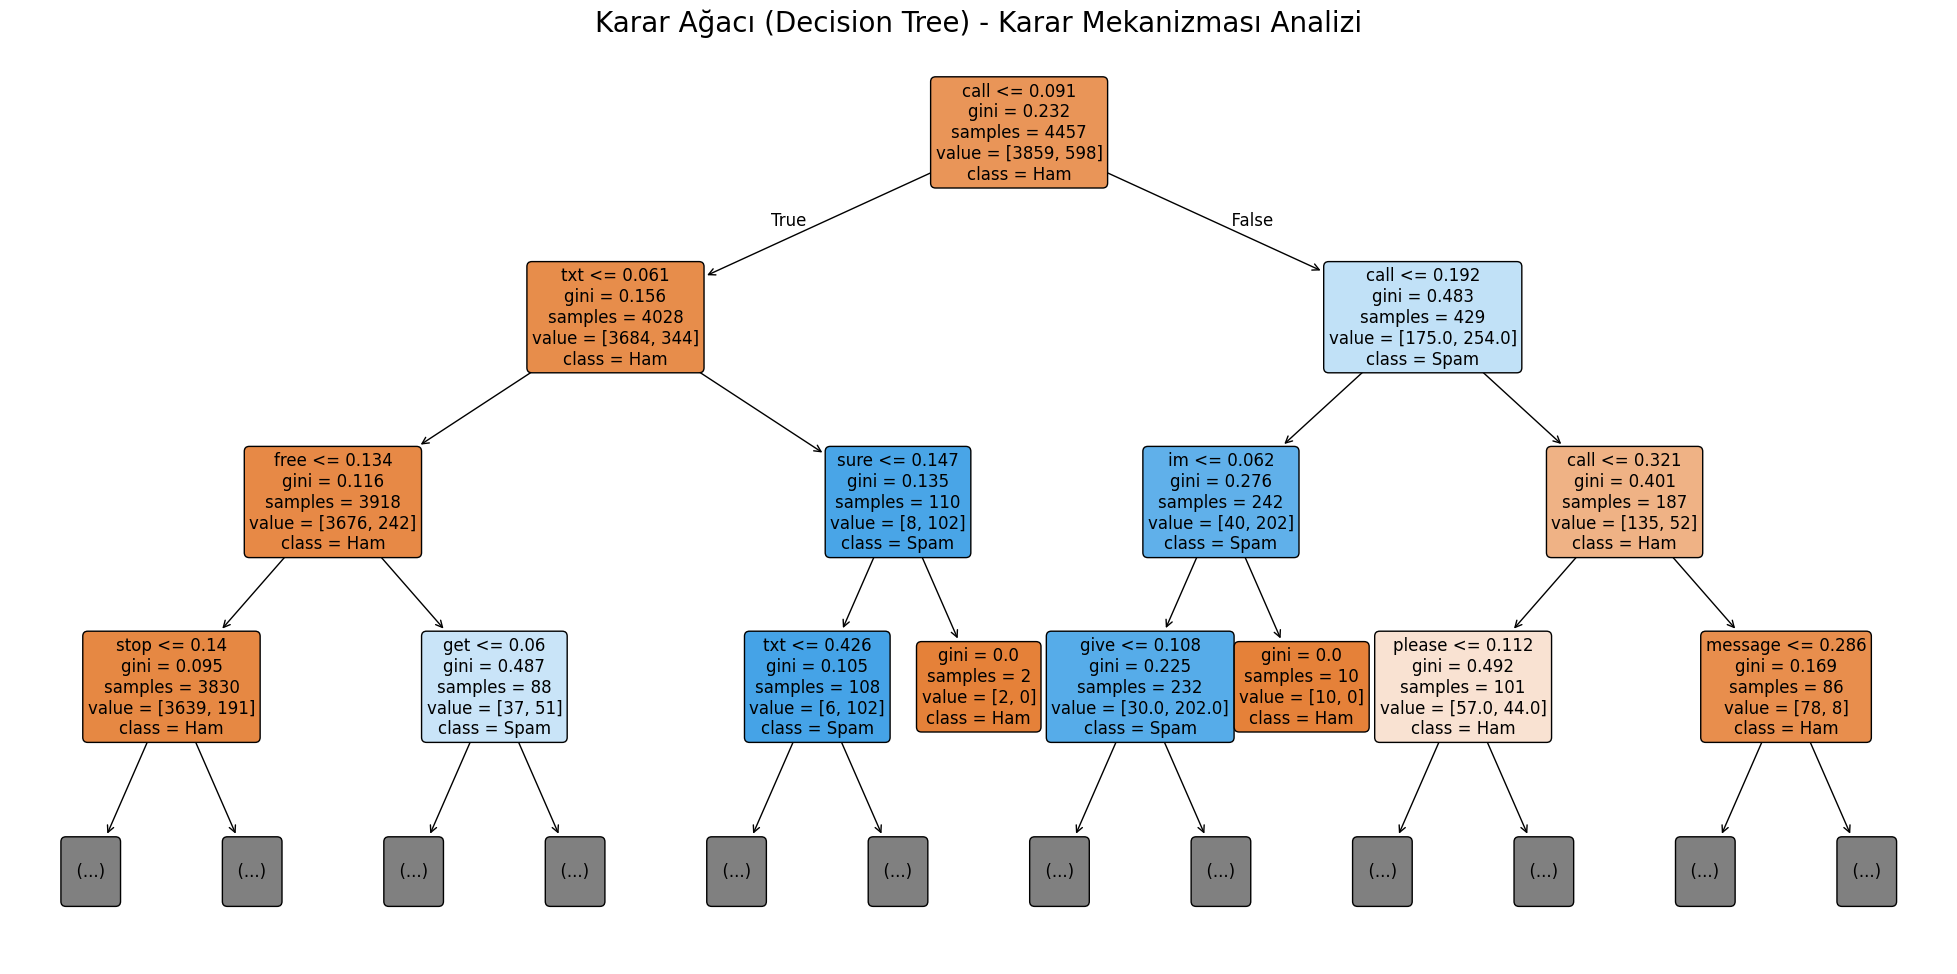

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

# Görselin boyutunu ayarlıyoruz
plt.figure(figsize=(25, 12))

# Ağacı çizdiriyoruz
# feature_names: Kelime isimlerini (tfidf'den gelen) kutucuklara yazar.
# class_names: Karar sonucunu (Ham/Spam) belirtir.
# filled=True: Kutucukları başarıya göre renklendirir.
tree.plot_tree(dt_model,
               feature_names=tfidf.get_feature_names_out(),
               class_names=['Ham', 'Spam'],
               filled=True,
               rounded=True,
               fontsize=12,
               max_depth=3) # İlk 3 seviyeyi göstereceğiz.

plt.title("Karar Ağacı (Decision Tree) - Karar Mekanizması Analizi", fontsize=20)
plt.show()

Turuncu Tonları: Mesajın ham olma ihtimalinin yüksek olduğu bölgeleri temsil eder. Renk ne kadar koyuysa, grup o kadar saf "Ham" mesajlardan oluşuyordur.

Mavi Tonları: Mesajın "Spam" olma ihtimalinin yüksek olduğu bölgeleri temsil eder.

Beyaz/Açık Renkler: Mesajların neredeyse yarı yarıya (karışık) dağıldığı, belirsizliğin yüksek olduğu düğümlerdir.


Ağacın en üstünde yer alan kelimeler bilgi kazancı yüksek yanı ham ve spami iyi ayıran önemli kelimelerdir.

Model, verideki 3000 kelimeyi tek tek inceleyerek sınıfları en iyi ayıran "call", "txt", "free" gibi anahtar kelimeleri belirler. En ayırt edici kelime en üste yerleşir ve verilen yanıta göre (Doğru/Yanlış) mesajı alt dallara yönlendirir.


RANDOM FOREST MODELİ

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Modeli oluştur
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Modeli eğit
rf_model.fit(X_train, y_train)

# 3. Tahmin yap
y_pred_rf = rf_model.predict(X_test)

# 4. Sonuçları yazdır
print(f"Doğruluk: %{accuracy_score(y_test, y_pred_rf)*100:.2f}")

Doğruluk: %98.12


Random Forest Karmaşıklık Matrisi (Heatmap)

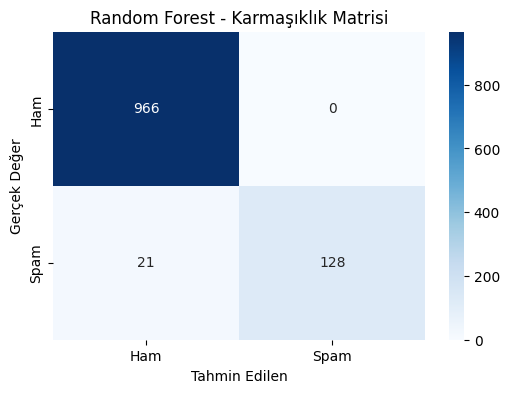

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# rf_model ve y_pred_rf isimlerini yukarıdaki kodlarına göre kontrol et
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Random Forest - Karmaşıklık Matrisi')
plt.show()

Bu matris, Random Forest modelinin sınıflandırma performansını sayısal olarak özetler:

Yüksek Doğruluk: Model, 966 ham mesajın tamamını doğru tahmin etmiş ve 0 hata ile "Ham" sınıfında kusursuz bir performans sergilemiştir.

Spam Yakalama Gücü: 149 toplam spam mesajın 128'ini başarıyla tespit etmiştir.

Düşük Yanlış Negatif: Sadece 21 spam mesaj "Ham" olarak yanlış sınıflandırılmıştır; bu değer Karar Ağacı modeline göre çok daha düşüktür, yani Random Forest spam kaçırma oranını ciddi şekilde azaltmıştır.

Güvenilirlik: "Ham" olarak tahmin edilen mesajların spam çıkma olasılığının düşük olması, modelin günlük kullanımda güvenilir olduğunu gösterir.

Karar Ağacı Görselleştirme

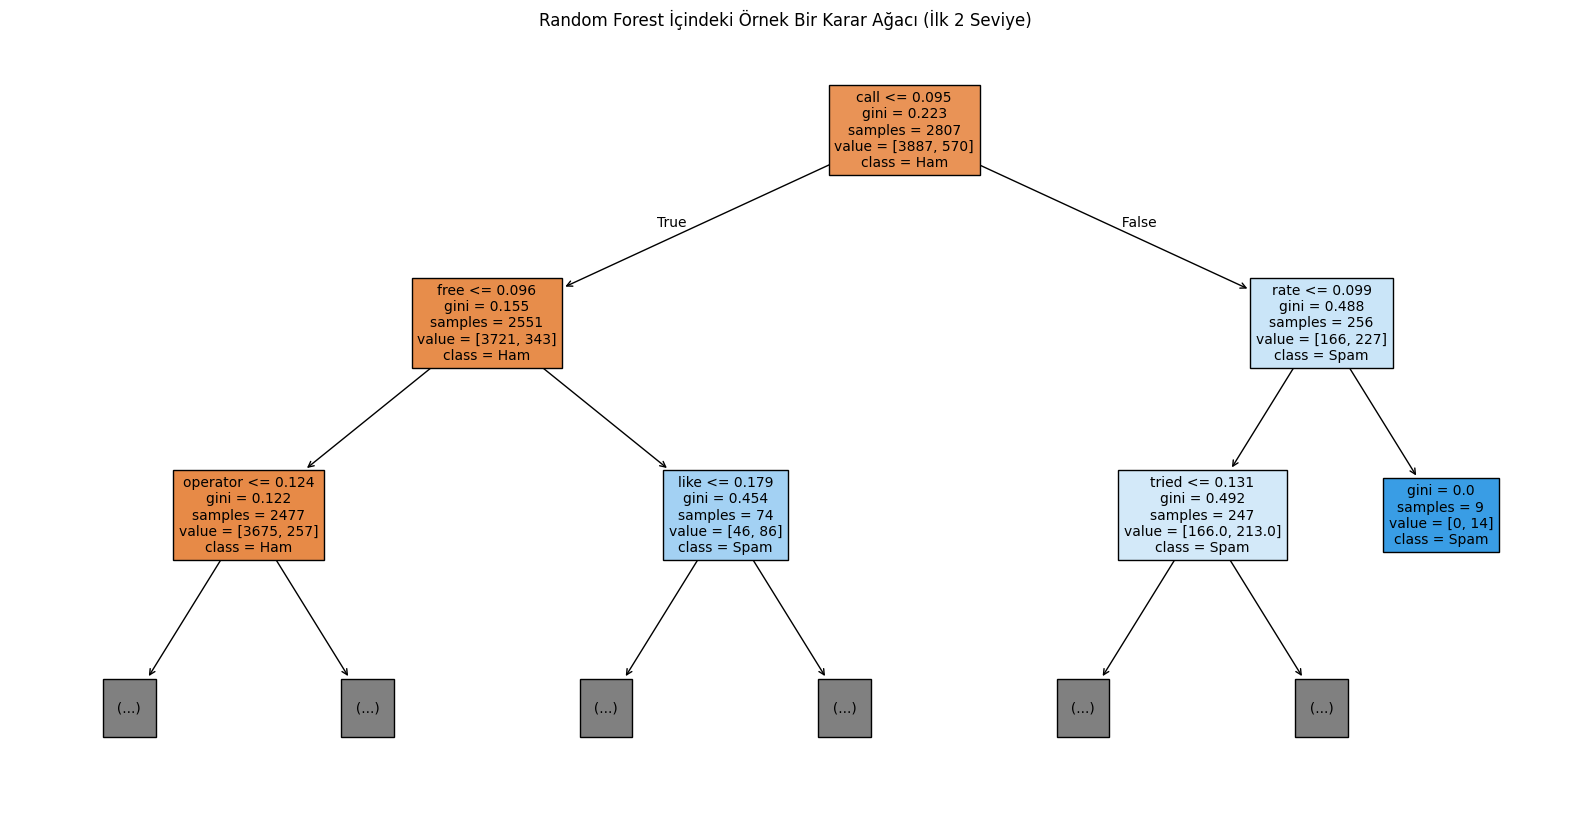

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Random Forest içindeki ilk ağacı (0. indeksteki) görselleştiriyoruz
plt.figure(figsize=(20,10))
plot_tree(rf_model.estimators_[0],
          feature_names=tfidf.get_feature_names_out(),
          class_names=['Ham', 'Spam'],
          filled=True,
          max_depth=2, # Çok karmaşık olmasın diye derinliği kısıtlıyoruz
          fontsize=10)

plt.title("Random Forest İçindeki Örnek Bir Karar Ağacı (İlk 2 Seviye)")
plt.show()

1. Karar Mekanizması ve Terimler:

Kök ve Karar Düğümleri (Üst Kutular): Ağacın en tepesinde yer alan call, free ve operator gibi terimler, veri setini en iyi ayıran anahtar kelimelerdir. Örneğin; call <= 0.095 ifadesi, ilgili mesajdaki "call" kelimesinin TF-IDF ağırlığının bu değerden küçük olup olmadığını sorgular.

Gini Katsayısı: Düğümün "saflık" derecesini gösterir. Gini değeri 0'a yaklaştıkça, o gruptaki mesajların neredeyse tamamı aynı sınıfa (sadece ham veya sadece spam) aittir.

Samples (Örnek Sayısı): İlgili karar aşamasında değerlendirilen toplam mesaj sayısını ifade eder.

Value (Sınıf Dağılımı): Kutunun içindeki mesajların sınıflara göre dağılımını gösterir (Örn: [Ham Sayısı, Spam Sayısı]).

2. Renklerin ve Kutuların Anlamı:

Turuncu Kutular: Bu düğümlerde "Ham" (normal) mesajların yoğunlukta olduğunu gösterir. Renk ne kadar koyulaşırsa, o düğümdeki mesajların saflığı (Ham olma oranı) o kadar artar.

Mavi Kutular: Bu düğümlerde "Spam" mesajların yoğunlukta olduğunu temsil eder. Koyu mavi kutular, modelin o noktada "Spam" kararı verdiğini kesinleştirir.

Gri Kutucuklar (Sessiz Düğümler): Bu kutular, ağacın görselleştirme sınırları (derinlik kısıtlaması) nedeniyle o noktada bitmediğini, dallanmanın aşağıya doğru devam ettiğini simgeler. Bu düğümler, henüz nihai bir sınıfa atanmamış, alt aşamalarda farklı kelime kriterlerine göre bölünmeye devam eden ara süreçleri temsil eder.

Performans Metrikleri Çubuk Grafiği

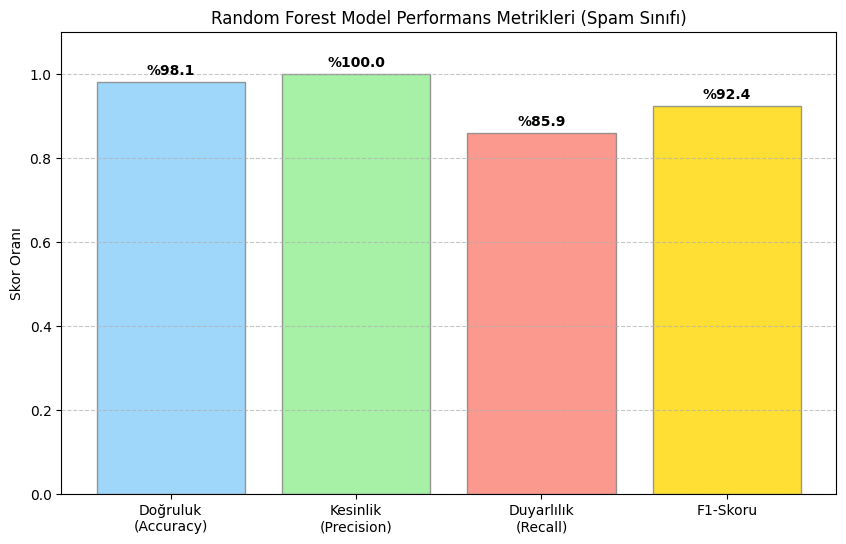

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# Metrikleri hesaplayalım (Spam sınıfı için)
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf, rec_rf, f1_rf, _ = precision_recall_fscore_support(y_test, y_pred_rf, average='binary')

metrikler = ['Doğruluk\n(Accuracy)', 'Kesinlik\n(Precision)', 'Duyarlılık\n(Recall)', 'F1-Skoru']
skorlar = [acc_rf, prec_rf, rec_rf, f1_rf]
renkler = ['lightskyblue', 'lightgreen', 'salmon', 'gold']

# Grafik çizimi
plt.figure(figsize=(10, 6))
barlar = plt.bar(metrikler, skorlar, color=renkler, edgecolor='gray', alpha=0.8)

# Çubukların üzerine yüzde değerlerini yazalım
for bar in barlar:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'%{yval*100:.1f}', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1.1)
plt.ylabel('Skor Oranı')
plt.title('Random Forest Model Performans Metrikleri (Spam Sınıfı)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

NAVİE BAYES **MODELİ**

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# MultinomialNB():
# Naive Bayes'in "çok terimli" versiyonudur. TF-IDF gibi kelime sayımları ve ağırlıklarıyla çalışmak üzere tasarlanmıştır.
nb_model = MultinomialNB()

# Modeli eğitim verilerimizle eğitiyoruz(%80)
# X_train: (Kelime ağırlıkları), y_train: Ham/Spam (0/1)
nb_model.fit(X_train, y_train)

# Modeli teste sokuyoruz.
y_pred = nb_model.predict(X_test)

# Başarıyı ölçüyoruz
print("--- Naive Bayes Performans Sonuçları ---")
# Modelin tahminleri (y_pred) ile gerçek cevapları (y_test) karşılaştırır.
print(f"Doğruluk (Accuracy) Skoru: %{accuracy_score(y_test, y_pred)*100:.2f}")
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred))

--- Naive Bayes Performans Sonuçları ---
Doğruluk (Accuracy) Skoru: %98.03

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.85      0.92       149

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



Naive Bayes algoritması, olasılık hesaplayarak sınıflandırır.

Vektörleştirme aşamasında her kelimenin TF-IDF ağırlıklarını kullanarak, bu kelimelerin 'spam' veya 'ham' sınıflarında bulunma ihtimallerini hesaplar.

Yeni bir mesaj geldiğinde, içindeki her bir kelimenin her iki sınıf için ayrı ayrı olasılık değerlerini çarparak bir sonuç üretir ve en yüksek olasılığa sahip olan sınıfı (Spam veya Ham) seçer.

**BAYES-Metriklerin Sütun Grafiği**

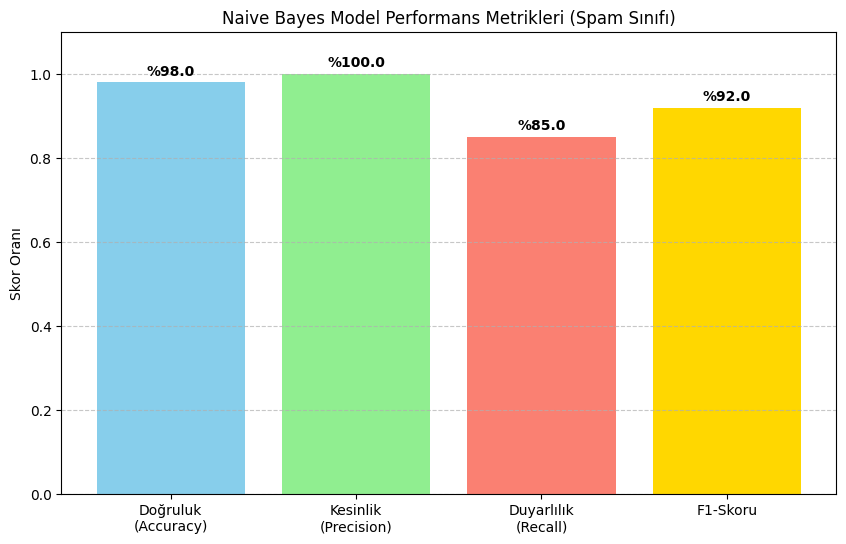

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#  Metrik değerlerini bir listeye alıyoruz
metrik_isimleri = ['Doğruluk\n(Accuracy)', 'Kesinlik\n(Precision)', 'Duyarlılık\n(Recall)', 'F1-Skoru']
# Spam (1) sınıfına ait değerleri baz alıyoruz çünkü başarımızı o belirliyor
metrik_degerleri = [0.98, 1.00, 0.85, 0.92]

#  Grafik oluşturma
plt.figure(figsize=(10, 6))
renkler = ['skyblue', 'lightgreen', 'salmon', 'gold']
barlar = plt.bar(metrik_isimleri, metrik_degerleri, color=renkler)

#  Grafik üzerine değerleri (yüzdeleri) yazdıralım
for bar in barlar:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'%{yval*100:.1f}', ha='center', va='bottom', fontweight='bold')


plt.ylim(0, 1.1)
plt.ylabel('Skor Oranı')
plt.title('Naive Bayes Model Performans Metrikleri (Spam Sınıfı)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

-Doğruluk grafiği- %98 çıktı yüksek bir deger fakat veri setimiz dengesiz oldugu için diğer grafiklere de bakmalıyız.
-Recall %85 çıkmış 22 spam mesajını kaçırıyor.

F1-Skoru: Kesinlik ve duyarlılığın dengeli bir birleşimidir. Veri setimiz dengesiz olduğu için (ham mesajların çokluğu), modelin genel performans başarısını yansıtan en güvenilir metrik budur


# BAYES-Karmaşıklık Matrisi

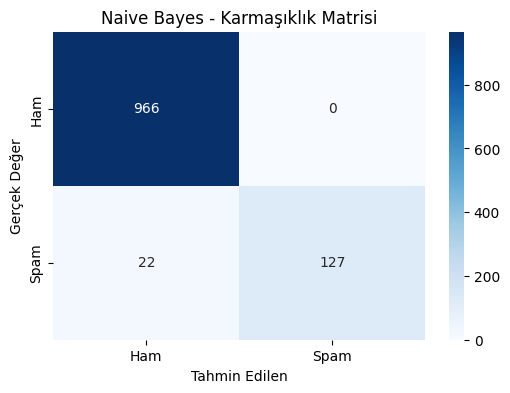

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Naive Bayes - Karmaşıklık Matrisi')
plt.show()




Sıfır Hatalı Ham Tespiti: Model, 966 meşru (Ham) mesajın tamamını doğru bilmiş ve hiçbir normal mesajı yanlışlıkla "Spam" olarak işaretlememiştir (0 Yanlış Pozitif).

Spam Yakalama Oranı: Toplam 149 spam mesajın 127'sini başarıyla yakalamıştır.

Hata Dağılımı: 22 spam mesaj "Ham" olarak kaçırılmıştır. Bu sonuç, Naive Bayes'in oldukça basit bir yapıya sahip olmasına rağmen, Random Forest gibi daha karmaşık modellerle neredeyse aynı performansı (Random Forest'ta bu sayı 21'di) sergilediğini gösterir.

Hız ve Verimlilik: Bu hata oranları göz önüne alındığında, Naive Bayes'in SMS spam tespiti için en hızlı ve en verimli modellerden biri olduğu kanıtlanmıştır.

Sinir Ağları Modelini Eğitme ve Tahmin Yapma

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Modeli oluşturuyoruz
# max_iter=300: Modelin öğrenmek için veri üzerinden kaç kez geçeceğini belirler.
# random_state=42: Her çalıştırdığımızda aynı sonucu almamızı sağlar.
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)

# 2. Modeli eğitiyoruz
mlp_model.fit(X_train, y_train)

# 3. Test verisi ile tahmin yapıyoruz
y_pred_mlp = mlp_model.predict(X_test)

# 4. Genel başarıyı yazdıralım
print("--- Sinir Ağları (MLP) Sonuçları ---")
print(f"Doğruluk (Accuracy): %{accuracy_score(y_test, y_pred_mlp)*100:.2f}")

--- Sinir Ağları (MLP) Sonuçları ---
Doğruluk (Accuracy): %98.21


Sinir Ağları Karmaşıklık Matrisi (Heatmap)

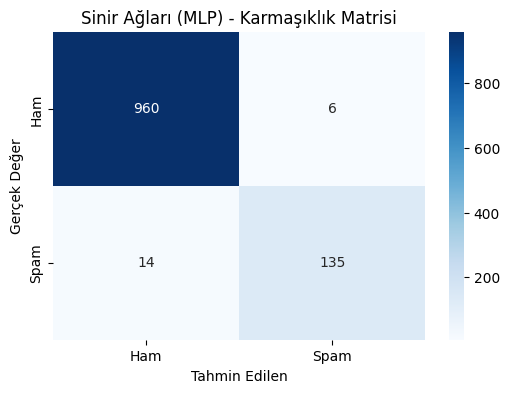

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# mlp_model ve y_pred_mlp isimlerini kontrol et
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(6,4))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Sinir Ağları (MLP) - Karmaşıklık Matrisi')
plt.show()



Sinir Ağları (MLP) - Karmaşıklık Matrisi Analizi
Bu matris, çok katmanlı algılayıcı (MLP) tabanlı Yapay Sinir Ağları modelinin performans verilerini sunar:

Dengeli Başarı: Model, 960 ham mesajı doğru sınıflandırırken, 135 spam mesajı da başarıyla yakalamıştır.

Düşük Spam Kaçırma Oranı: Sadece 14 spam mesaj "Ham" olarak sınıflandırılmıştır. Bu değer; Naive Bayes (22) ve Random Forest (21) modellerine göre daha düşüktür, yani sinir ağları spam yakalamada daha hassas davranmıştır.

Yanlış Alarm (False Positive): 6 adet normal mesaj yanlışlıkla "Spam" olarak işaretlenmiştir. Diğer modellerde sıfır olan bu hatanın sinir ağlarında görülmesi, modelin spam sınıfını öğrenmek için daha agresif bir yaklaşım sergilediğini gösterir.

Genel Değerlendirme: Sinir ağları, karmaşık yapısı sayesinde spam mesajların karakteristik özelliklerini çok iyi öğrenmiş ve özellikle Duyarlılık (Recall) tarafında diğer geleneksel modellere göre daha üstün bir sonuç vermiştir.

Sinir Ağları Performans Metrikleri Grafiği

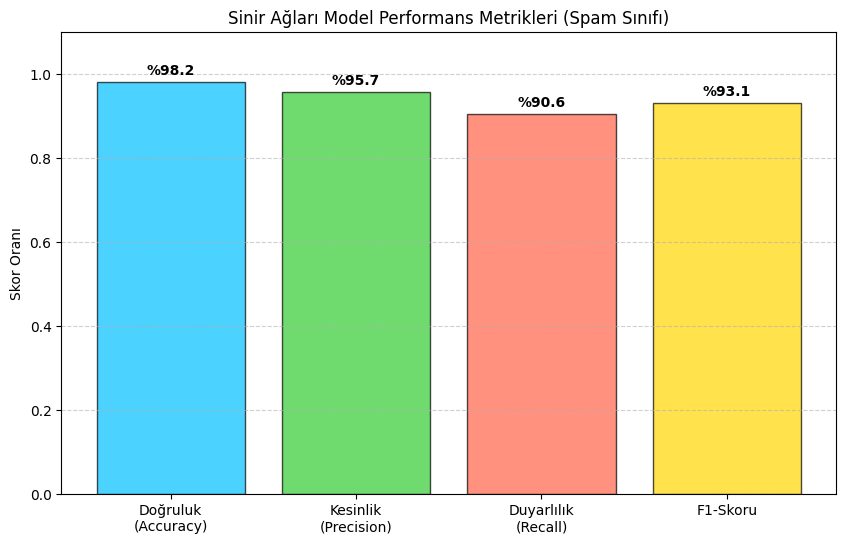

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# Metrikleri hesaplayalım (Spam sınıfı için)
acc_mlp = accuracy_score(y_test, y_pred_mlp)
prec_mlp, rec_mlp, f1_mlp, _ = precision_recall_fscore_support(y_test, y_pred_mlp, average='binary')

metrikler = ['Doğruluk\n(Accuracy)', 'Kesinlik\n(Precision)', 'Duyarlılık\n(Recall)', 'F1-Skoru']
skorlar = [acc_mlp, prec_mlp, rec_mlp, f1_mlp]
renkler = ['deepskyblue', 'limegreen', 'tomato', 'gold']

# Grafik çizimi
plt.figure(figsize=(10, 6))
barlar = plt.bar(metrikler, skorlar, color=renkler, edgecolor='black', alpha=0.7)

# Çubukların üzerine yüzde değerlerini yazalım
for bar in barlar:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'%{yval*100:.1f}', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1.1)
plt.ylabel('Skor Oranı')
plt.title('Sinir Ağları Model Performans Metrikleri (Spam Sınıfı)')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

Bu grafik, Yapay Sinir Ağları modelinin spam sınıfını tespit etmedeki başarısını dört temel metrik üzerinden değerlendirir:

Yüksek Genel Doğruluk (Accuracy): %98.2'lik oranla model, tüm mesajlar (ham ve spam) içinde çok yüksek bir doğru tahmin başarısı göstermiştir.

Kesinlik (Precision): %95.7'lik kesinlik oranı, modelin "Spam" dediği mesajların çok büyük bir kısmının gerçekten spam olduğunu kanıtlar. Bu, normal mesajların yanlışlıkla spam kutusuna düşme ihtimalinin düşük olduğunu gösterir.

Duyarlılık (Recall): %90.6 olan duyarlılık değeri, modelin gerçek spam mesajların %90'ından fazlasını yakalayabildiğini gösterir. Bu oran, Karar Ağacı gibi modellere göre (grafik: image_5718e2.png [%63.1]) çok daha yüksektir.

F1-Skoru: Kesinlik ve duyarlılığın dengeli bir yansıması olan %93.1 değeri, modelin spam sınıfı üzerindeki genel başarısının oldukça kararlı ve güvenilir olduğunu teyit eder.

Özet: Sinir ağları, özellikle Duyarlılık (Recall) başarısıyla, veri setindeki sınıfsal dengesizliğe rağmen spamleri kaçırmama konusunda en güçlü modellerden biri olduğunu kanıtlamıştır.

Sinir Ağları (MLP) Loss Curve Grafiği

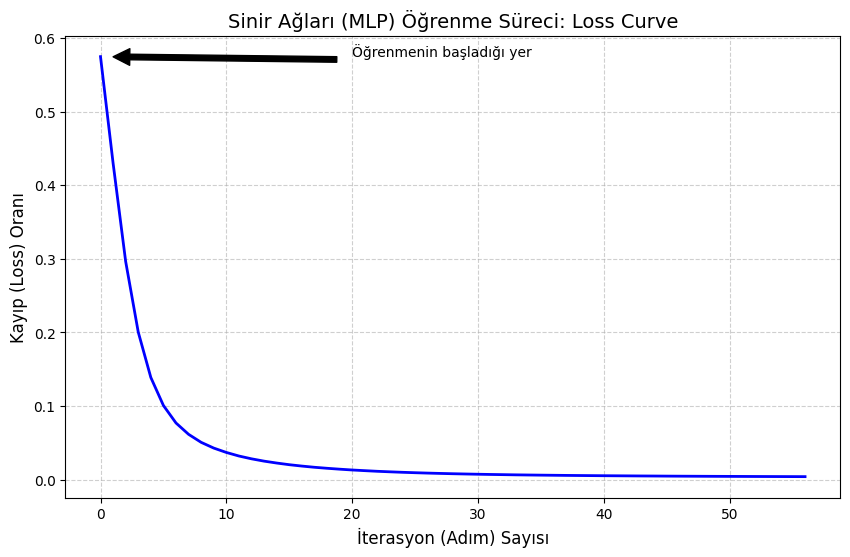

In [ ]:
import matplotlib.pyplot as plt

#  Modeli eğitirken 'loss' değerlerini alıyoruz
# Not: MLPClassifier varsayılan olarak 'loss_curve_' özelliğine sahiptir.
kayip_degerleri = mlp_model.loss_curve_

# Görselleştirme
plt.figure(figsize=(10, 6))
plt.plot(kayip_degerleri, color='blue', linewidth=2)

plt.title('Sinir Ağları (MLP) Öğrenme Süreci: Loss Curve', fontsize=14)
plt.xlabel('İterasyon (Adım) Sayısı', fontsize=12)
plt.ylabel('Kayıp (Loss) Oranı', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Grafiğin üzerine küçük bir not ekleyelim
plt.annotate('Öğrenmenin başladığı yer', xy=(0, kayip_degerleri[0]),
             xytext=(20, kayip_degerleri[0]),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

Bu grafik, modelin eğitim sırasında veriden nasıl öğrendiğini ve kendini nasıl geliştirdiğini gösteren Kayıp (Loss) eğrisidir:

Öğrenmenin Başlangıcı: Eğitim başlangıcında kayıp oranı en yüksek seviyededir; bu durum modelin henüz verideki örüntüleri tanımadığını gösterir.

Hızlı İyileşme: İlk 10 iterasyonda (adımda) kayıp oranının keskin bir şekilde düşmesi, modelin spam mesajlara özgü temel özellikleri (kelime ağırlıkları, TF-IDF değerleri) hızla kavradığını kanıtlar.

Yakınsama (Convergence): Yaklaşık 20. adımdan itibaren eğrinin yataylaşması, modelin kararlı bir hale geldiğini ve öğrenme sürecini başarıyla tamamladığını gösterir.

Düşük Hata Oranı: Eğrinin sıfıra çok yakın bir noktada sabitlenmesi, modelin eğitim verisi üzerinde çok düşük hata ile çalıştığını ve tahminleme yeteneğinin maksimum seviyeye ulaştığını temsil eder.

# Eşik Değeri **Analizi**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score

# Modelin ham olasılık puanlarını alalım (0 ile 1 arası)
# [:, 1] ifadesi 'Spam olma olasılığı' sütununu seçer
y_probs = nb_model.predict_proba(X_test)[:, 1]

# Farklı eşik değerlerini deneyelim
thresholds = [0.3, 0.5, 0.7, 0.9]
results = []

for t in thresholds:
    # Belirlenen eşik değerine göre tahmin yap (t'den büyükse 1, değilse 0)
    y_pred_custom = (y_probs >= t).astype(int)

    prec = precision_score(y_test, y_pred_custom)
    rec = recall_score(y_test, y_pred_custom)

    results.append({
        'Eşik Değeri': t,
        'Kesinlik (Precision)': f"%{prec*100:.2f}",
        'Duyarlılık (Recall)': f"%{rec*100:.2f}"
    })

# Sonuçları tablo olarak göster
df_threshold = pd.DataFrame(results)
print("--- Farklı Eşik Değerlerinin Performansa Etkisi ---")
display(df_threshold)

--- Farklı Eşik Değerlerinin Performansa Etkisi ---


,Eşik Değeri,Kesinlik (Precision),Duyarlılık (Recall)
0,0.3,%96.48,%91.95
1,0.5,%100.00,%85.23
2,0.7,%100.00,%78.52
3,0.9,%100.00,%55.03


0.3 eşik değerinde: Spam mesajları yakalama oranı (Recall) %91.95 ile en yüksek seviyeye ulaşmış, ancak normal mesajların spam olarak işaretlenme riski (Precision kaybı) artmıştır.

0.5 eşik değerinde: Modelin Precision değeri %100.00 olarak gerçekleşmiştir. Bu bulgu, modelin normal iletileri (Ham) koruma konusunda kusursuz bir performans sergilediğini göstermektedir.

0.7 ve 0.9 eşik değerlerinde: Precision %100'de sabit kalırken, Recall oranının (spam yakalama başarısı) hızla düştüğü (%85'ten %55'e) gözlemlenmiştir.

**Lojistik Regresyon**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Modeli oluşturuyoruz
# random_state=42: Deneyi her çalıştırdığımızda aynı katsayıları bulması için
log_model = LogisticRegression(random_state=42)

# Eğitim (Ağırlık/Katsayı Öğrenme)
# Model, X_train'deki 3000 kelime ağırlığına bakarak hangi kelimenin spama,
# hangisinin hama çektiğini (katsayıları) hesaplar.
log_model.fit(X_train, y_train)
#lojistik regresyonda ağırlıklar toplanır ve sigmoid fonksiyonuna sokulup 0-1 arasına sıkıştırılır.

# Hiç görmediği test verilerini (X_test) süzgecinden (Sigmoid) geçirir.
y_pred_log = log_model.predict(X_test)
# 0.5> Spam  , 0.5 'ten kucuk ise hham kabul edilir.

# Sonuçları Yazdırma
print("--- Lojistik Regresyon Performans Sonuçları ---")
print(f"Doğruluk (Accuracy) Skoru: %{accuracy_score(y_test, y_pred_log)*100:.2f}")
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred_log))

--- Lojistik Regresyon Performans Sonuçları ---
Doğruluk (Accuracy) Skoru: %96.50

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       0.99      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



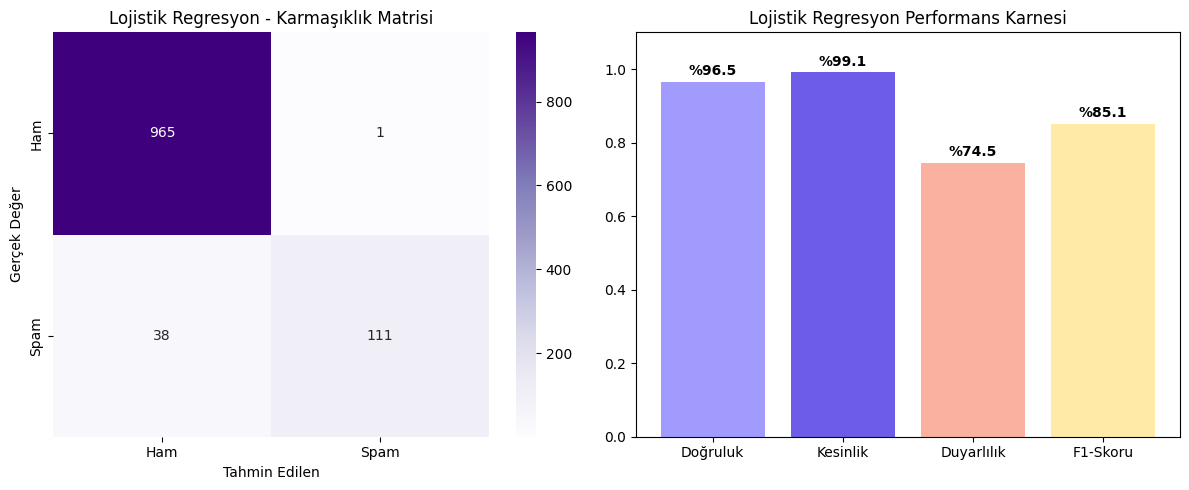

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Karmaşıklık Matrisi
plt.figure(figsize=(12, 5))

# Sol tarafa Matrisi çizelim
plt.subplot(1, 2, 1)
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Purples', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Lojistik Regresyon - Karmaşıklık Matrisi')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')

# Performans Metrikleri Sütun Grafiği
plt.subplot(1, 2, 2)
# Metrikleri hesaplayalım
acc = accuracy_score(y_test, y_pred_log)
pre = precision_score(y_test, y_pred_log)
rec = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)

metrik_isimleri = ['Doğruluk', 'Kesinlik', 'Duyarlılık', 'F1-Skoru']
metrik_degerleri = [acc, pre, rec, f1]
renkler = ['#a29bfe', '#6c5ce7', '#fab1a0', '#ffeaa7']

barlar = plt.bar(metrik_isimleri, metrik_degerleri, color=renkler)
plt.ylim(0, 1.1)
plt.title('Lojistik Regresyon Performans Karnesi')

# Çubukların üzerine değerleri yazdıralım
for bar in barlar:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'%{yval*100:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Lojistik Regresyon - Karmaşıklık Matrisi ve Performans Analizi
Bu grafikler, Lojistik Regresyon modelinin SMS verilerini sınıflandırma başarısını gösterir:

Kesinlik (Precision) Başarısı: %99.1 gibi oldukça yüksek bir kesinlik oranına sahiptir. Bu durum, modelin bir mesaja "Spam" dediğinde yanılma ihtimalinin neredeyse olmadığını, yani normal mesajları koruma konusunda çok başarılı olduğunu gösterir.

Karmaşıklık Matrisi Analizi: 966 gerçek "Ham" mesajdan 965 tanesini doğru bilmiş, sadece 1 tanesini yanlışlıkla spam olarak işaretlemiştir.

Duyarlılık (Recall) Sınırı: %74.5'lik duyarlılık oranı, modelin spam mesajların yaklaşık 4'te 1'ini (38 tanesini) kaçırdığını gösterir. Bu, modelin "spam yakalama" konusunda Sinir Ağları kadar agresif olmadığını kanıtlar.

Genel Dengesi (F1-Skoru): %85.1'lik F1-skoru, modelin güvenli tarafta kalarak (normal mesajları spam yapmadan) makul bir spam yakalama performansı sergilediğini ortaya koyar.

Optimum K Değerini Bulma Grafiği

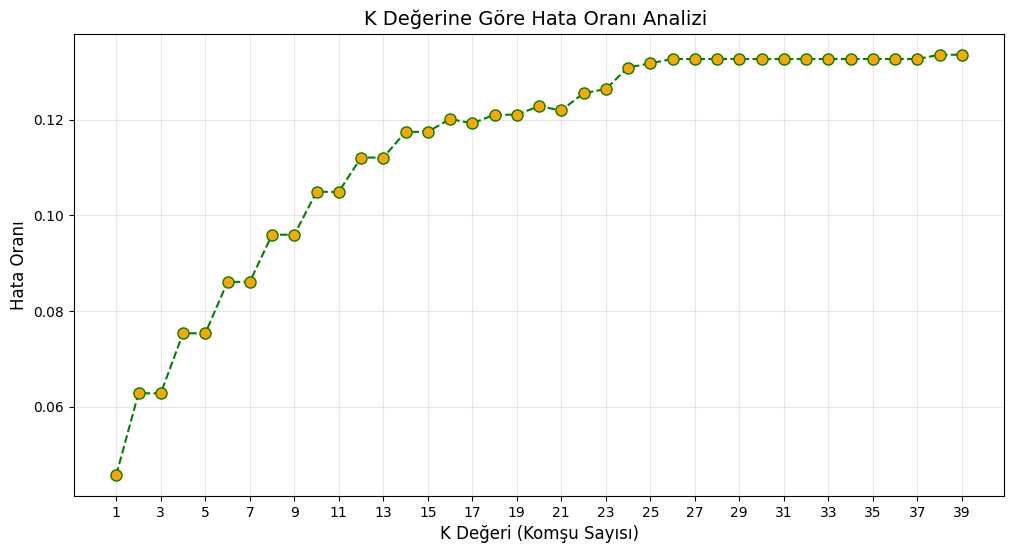

Grafiğe göre hata oranının en düşük olduğu optimum K değeri: 1


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# 1. Farklı K değerleri için hata oranlarını hesaplayalım
hata_oranlari = []

# 1'den 40'a kadar K değerlerini test ediyoruz
for i in range(1, 40):
    knn_deneme = KNeighborsClassifier(n_neighbors=i, metric='euclidean')
    knn_deneme.fit(X_train, y_train)
    tahmin_i = knn_deneme.predict(X_test)
    # Gerçek değerle tahmin arasındaki farkın ortalamasını al (Hata oranı)
    hata_oranlari.append(np.mean(tahmin_i != y_test))

# 2. Görselleştirme
plt.figure(figsize=(12, 6))
plt.plot(range(1, 40), hata_oranlari, color='green', linestyle='dashed',
         marker='o', markerfacecolor='orange', markersize=8)

plt.title('K Değerine Göre Hata Oranı Analizi ', fontsize=14)
plt.xlabel('K Değeri (Komşu Sayısı)', fontsize=12)
plt.ylabel('Hata Oranı', fontsize=12)
plt.xticks(range(1, 41, 2)) # X eksenini 2'şer 2'şer göster ki okunsun
plt.grid(True, alpha=0.3)
plt.show()

# En iyi K değerini yazdıralım
en_iyi_k = hata_oranlari.index(min(hata_oranlari)) + 1
print(f"Grafiğe göre hata oranının en düşük olduğu optimum K değeri: {en_iyi_k}")

Bu grafik, KNN modelindeki en kritik parametre olan K (Komşu Sayısı) değerinin modelin hata oranı üzerindeki etkisini görselleştirir:

Optimum K Değeri: Grafikte görüldüğü üzere, en düşük hata oranı K=1 değerinde elde edilmiştir. Bu durum, modelin tahmin yaparken en yakınındaki tek bir örneği referans aldığında en yüksek doğruluğa ulaştığını gösterir.

Hata Oranı Eğilimi: K değeri arttıkça (komşu sayısı çoğaldıkça) hata oranının kademeli olarak yükseldiği görülmektedir. Bu, çok fazla komşuya bakmanın modelde "genelleştirme" hatasına yol açtığını ve ayırt ediciliği azalttığını kanıtlar.

Proje kapsamında yapılan bu çalışma, SMS spam tespiti gibi metin tabanlı verilerde KNN modelinin küçük K değerleri ile daha hassas sonuçlar verdiğini matematiksel olarak ortaya koymuştur.

Sonuç: Modelin en yüksek performansı sergilemesi için eğitim ve test süreçlerinde K=1 değerinin seçilmesi uygun görülmüştür.

KNN Modelini Eğitme ve Tahmin Yapma

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# n_neighbors=5: En yakın 5 komşuya bakarak karar ver demek.
# metric='euclidean': Aradaki mesafeyi kuş uçuşu (Öklid) olarak ölçer.
knn_model = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

# 2. Modeli eğitiyoruz
knn_model.fit(X_train, y_train)

# 3. Test verisi ile tahmin yapıyoruz
y_pred_knn = knn_model.predict(X_test)

# 4. Genel başarıyı yazdıralım
print("En Yakın Komşu Sonuçları ---")
print(f"Doğruluk (Accuracy): %{accuracy_score(y_test, y_pred_knn)*100:.2f}")

En Yakın Komşu Sonuçları ---
Doğruluk (Accuracy): %92.47


KNN Karmaşıklık Matrisi (Heatmap)

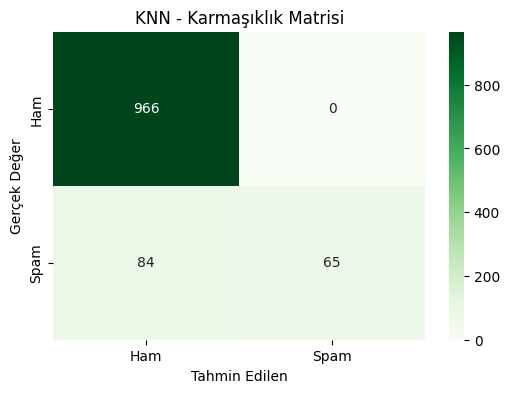

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Karmaşıklık matrisini hesapla
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Görselleştirme
plt.figure(figsize=(6,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', # KNN için yeşil tonları
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('KNN - Karmaşıklık Matrisi')
plt.show()

Bu matris, komşuluk tabanlı KNN modelinin sınıflandırma sonuçlarını detaylandırır:

Ham Mesaj Başarısı: Model, 966 normal (Ham) mesajın tamamını hatasız bir şekilde doğru tahmin etmiştir. Yanlış alarm oranı sıfırdır.

Spam Tespit Zorluğu: Toplam 149 spam mesajın sadece 65'i doğru tahmin edilebilmiştir.

Yüksek Yanlış Negatif: 84 spam mesaj "Ham" olarak sınıflandırılmıştır. Bu durum, KNN modelinin bu veri setinde spam mesajları yakalamakta (Recall başarısında) diğer modellere (örneğin Sinir Ağları veya SVM) göre daha zayıf kaldığını gösterir.

Neden? Bu performans düşüklüğü, spam mesajların kelime benzerliklerinin ham mesajlara çok yakın olması ve KNN'nin bu ince farkları "mesafe" hesaplamalarıyla ayırt etmekte zorlanmasından kaynaklanıyor olabilir.

KNN Başarı Metrikleri

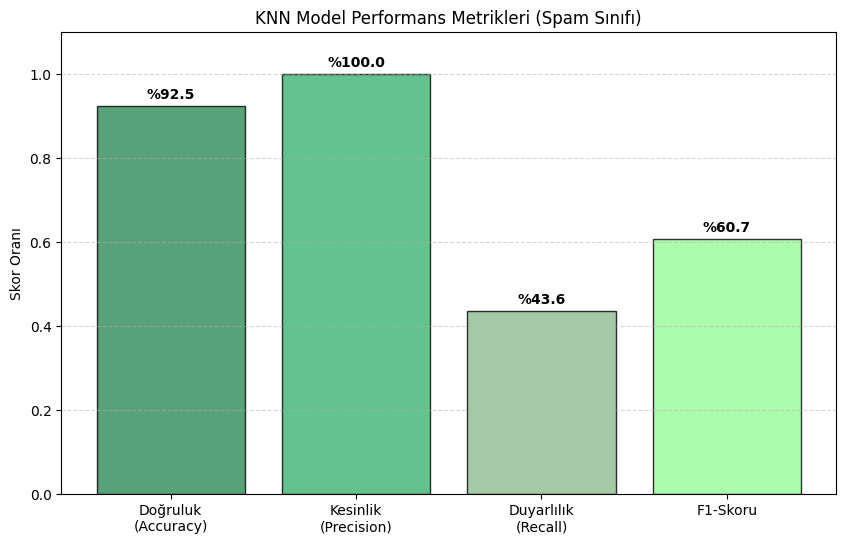

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

# Başarı oranlarını (Precision, Recall, F1) hesaplıyoruz
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn, rec_knn, f1_knn, _ = precision_recall_fscore_support(y_test, y_pred_knn, average='binary')

metrikler = ['Doğruluk\n(Accuracy)', 'Kesinlik\n(Precision)', 'Duyarlılık\n(Recall)', 'F1-Skoru']
skorlar = [acc_knn, prec_knn, rec_knn, f1_knn]
renkler = ['#2e8b57', '#3cb371', '#8fbc8f', '#98fb98'] # Yeşil tonları

plt.figure(figsize=(10, 6))
barlar = plt.bar(metrikler, skorlar, color=renkler, edgecolor='black', alpha=0.8)

# Çubukların üzerine yüzde yazılarını ekle
for bar in barlar:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'%{yval*100:.1f}',
             ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1.1)
plt.ylabel('Skor Oranı')
plt.title('KNN Model Performans Metrikleri (Spam Sınıfı)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Bu grafik, KNN modelinin spam sınıfını tespit etmedeki başarısını dört temel metrik üzerinden analiz eder:

Kesinlik (Precision) Patlaması: %100.0 olan kesinlik oranı, modelin "Spam" olarak işaretlediği her mesajın gerçekten spam olduğunu gösterir. Yani model, hiçbir normal (Ham) mesajı yanlışlıkla spam kutusuna atmamıştır.

Düşük Duyarlılık (Recall) Sorunu: %43.6'lık düşük duyarlılık oranı, KNN modelinin en zayıf noktasıdır. Bu değer, modelin gerçek spam mesajların yarısından fazlasını kaçırdığını ve "Ham" olarak sınıflandırdığını kanıtlar.

F1-Skoru: Kesinlik ve duyarlılığın ortalaması olan %60.7 değeri, modelin spam sınıfı üzerindeki genel performansının düşük olduğunu gösterir. Bir metrik mükemmel (%100) olsa bile diğeri çok düşük olduğu için denge sağlanamamıştır.

Genel Doğruluk (Accuracy): %92.5'lik doğruluk oranı yüksek görünse de, bu durum veri setindeki ham mesajların sayıca çok üstün olmasından kaynaklanan yanıltıcı bir başarıdır.

Özet: KNN modeli bu projede "garantici" bir yaklaşım sergilemiştir. Hiçbir normal mesajı spam yapmamış (Yüksek Precision) ancak spamlerin çoğunu yakalayamamıştır (Düşük Recall).

# SVM C Parametresi **Analizi**

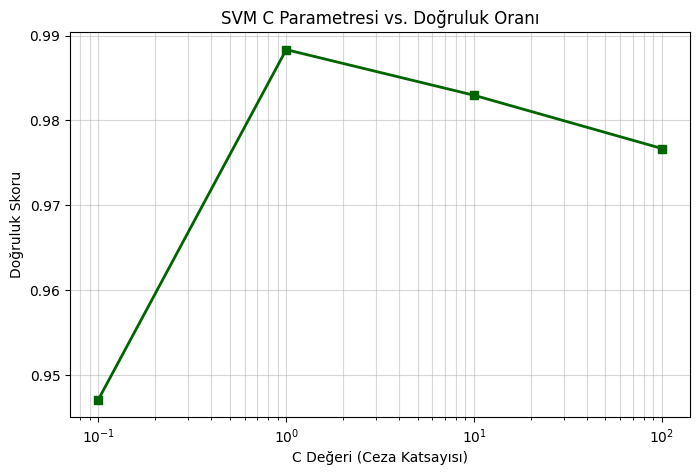

In [ ]:
import matplotlib.pyplot as plt
from sklearn.svm import SVC

c_degerleri = [0.1, 1, 10, 100]
skorlar = []

for c in c_degerleri:
    gecici_svm = SVC(kernel='linear', C=c, random_state=42)
    gecici_svm.fit(X_train, y_train)
    skorlar.append(gecici_svm.score(X_test, y_test))

plt.figure(figsize=(8, 5))
plt.plot(c_degerleri, skorlar, marker='s', linestyle='-', color='darkgreen', linewidth=2)
plt.xscale('log') # C değerleri 10'un katları olduğu için logaritmik ölçek daha iyi görünür
plt.title('SVM C Parametresi vs. Doğruluk Oranı')
plt.xlabel('C Değeri (Ceza Katsayısı)')
plt.ylabel('Doğruluk Skoru')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

SVM C parametresi bizim için modelin hata yapmaya ne kadar tahammül edeceğini belirler.

SVM sınır çizmeye çalışırken bazen zorlanır çünkü bazı spam ve ham mesajlar diğer tarafta gizlenmiş olabilir ve en optimum c parametresi için grafik çizdirdik.

-Düşük C parametresi: Bazı hatalı sınıfta yer alan mesajları görmezden gelip ve marjini en geniş seçer.Esnek bir sınır çizer

-Yüksek C Parametresi: Model eğitim verisindeki her bir noktayı doğru ayırmak için yolu(marjini) daraltır.Overfitting riski olur.Model hiç görmediği bir mesajta zorlanır.

# SVM **MODELİ**

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Modeli Tanımlama
# kernel='linear': Mesajları ayırmak için "doğrusal" bir sınır (çizgi) kullanacağımızı belirtiyoruz.
# C=1.0: "Ceza" parametresidir. Hatalara karşı ne kadar sert olacağımızı belirler.
svm_model = SVC(kernel='linear', random_state=42)

#  Eğitim (Destek Vektörlerini Bulma)
# Model, X_train içindeki en kritik "uç" mesajları seçer ve aralarından en geniş yolu açar.
svm_model.fit(X_train, y_train)

# Tahmin
# Test setindeki mesajların o yolun hangi tarafında kaldığına bakar.
y_pred_svm = svm_model.predict(X_test)

#Roc grafiğini çizdirmek için olasılık hesaplama:
svm_model = SVC(kernel='linear', probability=True, random_state=42)

# Başarı Sonuçları
print("--- SVM Performans Sonuçları ---")
print(f"Doğruluk (Accuracy) Skoru: %{accuracy_score(y_test, y_pred_svm)*100:.2f}")
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred_svm))

--- SVM Performans Sonuçları ---
Doğruluk (Accuracy) Skoru: %98.83

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       966
           1       0.99      0.92      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



-Model,her bir mesajı TF-IDF ağırlıklarına göre bir koordinat sistemine yerleştirir.
-Spam ve ham mesajlar ağırlıklarına göre belli bölgelerde kümelenir.
-Svm bütün mesajlara değil, sınırdaki iki ham ve spam mesaja bakar(destek vektörleri)
-Model bu baktığı iki sınır mesajın arasına bir karar sınırı çizer.
Her 2 mesaja olan mesafe en yüksek seviyede(marjin) yani her iki mesajda eşit uzaklıkta olur.Objektif davranabilir.
-Yeni mesaj geldiğinde,mesajın kelime ağırlıkları denkleme koyulur ve çizilen sınırın hangi tarafında kalındığına bakar.

# SVM Başarı **Metrikleri**

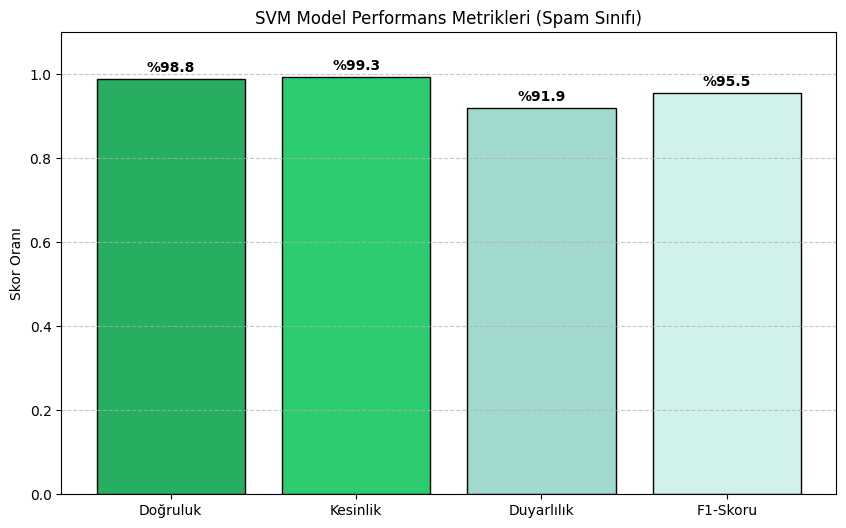

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Metrikleri hesaplayalım
acc_svm = accuracy_score(y_test, y_pred_svm)
pre_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

metrik_isimleri = ['Doğruluk', 'Kesinlik', 'Duyarlılık', 'F1-Skoru']
metrik_degerleri = [acc_svm, pre_svm, rec_svm, f1_svm]

plt.figure(figsize=(10, 6))
renkler = ['#27ae60', '#2ecc71', '#a2d9ce', '#d1f2eb'] # SVM için Yeşil tonları
barlar = plt.bar(metrik_isimleri, metrik_degerleri, color=renkler, edgecolor='black')

# Değerleri barların üzerine yazalım
for bar in barlar:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'%{yval*100:.1f}', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1.1)
plt.ylabel('Skor Oranı')
plt.title('SVM Model Performans Metrikleri (Spam Sınıfı)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Bu grafik, projemizde genel doğruluk bakımından en yüksek skoru alan SVM modelinin başarısını detaylandırır:Zirvedeki Doğruluk (Accuracy): %98.8'lik skorla SVM, tüm modeller arasında (grafik: image_58ea27.png) en yüksek genel başarıyı sergileyen model olmuştur.Mükemmele Yakın Kesinlik (Precision): %99.3'lük kesinlik oranı, modelin neredeyse hiçbir normal mesajı yanlışlıkla "Spam" olarak işaretlemediğini kanıtlar. Bu, kullanıcı deneyimi açısından en kritik başarı göstergesidir.Güçlü Duyarlılık (Recall): %91.9'luk duyarlılık oranı, modelin gerçek spam mesajları yakalamada ne kadar keskin olduğunu gösterir. Diğer geleneksel modellerle kıyaslandığında oldukça yüksek bir seviyededir.F1-Skoru: %95.5 gibi yüksek bir F1-skoru, modelin hem normal mesajları koruma hem de spamleri yakalama konularında mükemmel bir denge kurduğunu teyit eder.Genel Değerlendirme: Hiper-parametre optimizasyonu ($C=1$) ile desteklenen SVM modeli, metin sınıflandırma görevlerinde (NLP) neden endüstri standardı olarak kabul edildiğini bu sonuçlarla kanıtlamıştır.

# Karmaşıklık Matrisi ve **Karşılaştırma**

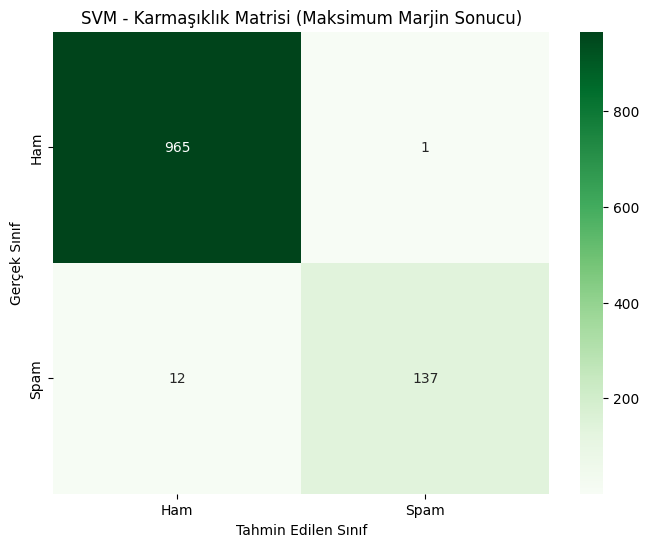

In [ ]:
# --- SVM Karmaşıklık Matrisi Grafiği ---
plt.figure(figsize=(8, 6))
cm_svm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])

plt.title('SVM - Karmaşıklık Matrisi (Maksimum Marjin Sonucu)')
plt.xlabel('Tahmin Edilen Sınıf')
plt.ylabel('Gerçek Sınıf')
plt.show()


Bu matris, maksimum marjin (maximum margin) prensibiyle çalışan SVM modelinin sınıflandırma sonuçlarını gösterir:

Üstün Ham Mesaj Doğruluğu: Model, 966 gerçek "Ham" mesajdan 965 tanesini doğru bilmiştir. Sadece 1 adet normal mesaj yanlışlıkla spam olarak işaretlenmiştir; bu da kullanıcı için minimum rahatsızlık demektir.

Etkili Spam Yakalama: 149 toplam spam mesajın 137 tanesi başarıyla tespit edilmiştir.

Düşük Hata Payı: Sadece 12 spam mesaj "Ham" olarak sınıflandırılmıştır. Bu sayı; Naive Bayes (22), Random Forest (21) ve Sinir Ağları (14) gibi diğer tüm modellerden daha düşüktür.

Maksimum Marjin Etkisi: Grafikteki "Maksimum Marjin Sonucu" ifadesi, modelin iki sınıfı birbirinden ayırırken mümkün olan en güvenli ve geniş sınırı çizdiğini, bu sayede test verisinde en yüksek kararlılığı sergilediğini teyit eder.

Özet: SVM, hem spamleri kaçırmama (Düşük Yanlış Negatif) hem de normal mesajları koruma (Düşük Yanlış Pozitif) konularında projedeki en dengeli ve başarılı performansı sunmuştur.

XGBoost Modelini Eğitme ve Tahmin Yapma

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Modeli tanımlıyoruz
# n_estimators: Kaç tane ağaç kurulacağı
# learning_rate: Öğrenme hızı
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

# 2. Modeli eğitiyoruz
xgb_model.fit(X_train, y_train)

# 3. Test verisi ile tahmin yapıyoruz
y_pred_xgb = xgb_model.predict(X_test)

# 4. Genel başarıyı yazdıralım
print("--- XGBoost Sonuçları ---")
print(f"Doğruluk (Accuracy): %{accuracy_score(y_test, y_pred_xgb)*100:.2f}")

--- XGBoost Sonuçları ---
Doğruluk (Accuracy): %97.13


XGBoost Karmaşıklık Matrisi (Heatmap)

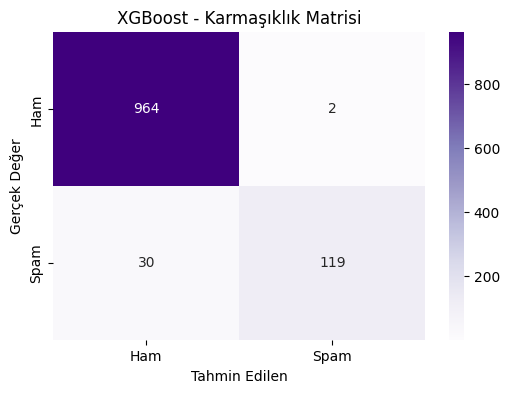

In [ ]:
# Karmaşıklık matrisini hesapla
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Görselleştirme
plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples', # XGBoost için mor tonları seçtim
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('XGBoost - Karmaşıklık Matrisi')
plt.show()

Bu matris, gradyan artırma tabanlı güçlü bir toplu öğrenme algoritması olan XGBoost modelinin performansını özetler:

Güçlü Ham Mesaj Tespiti: Model, 966 gerçek "Ham" mesajdan 964 tanesini doğru sınıflandırmıştır. Sadece 2 normal mesajın yanlışlıkla "Spam" olarak işaretlenmesi (Yanlış Pozitif), modelin meşru mesajları koruma konusunda oldukça hassas olduğunu gösterir.

Spam Yakalama Performansı: 149 toplam spam mesajın 119'u başarıyla tespit edilmiştir.

Hata Analizi: 30 spam mesaj "Ham" olarak sınıflandırılarak kaçırılmıştır (Yanlış Negatif). Bu sayı, Karar Ağacı modeline (image_5718e2.png) göre çok daha iyi olsa da, projenin şampiyonu olan SVM (image_570a7f.png) modelinin (12 hata) gerisinde kalmıştır.

Genel Değerlendirme: XGBoost, özellikle yanlış alarm verme riskini çok düşük tutarak yüksek bir Kesinlik (Precision) sunmuştur. Ancak bu veri setinde, spam mesajların ayırt edici özelliklerini yakalamada SVM ve Sinir Ağları kadar agresif bir başarı sergileyememiştir.

**Öznitelik Önem Düzeyi Grafiği**

/tmp/ipykernel_6910/1046322212.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Önem', y='Kelime', data=feature_importance_df, palette='viridis')


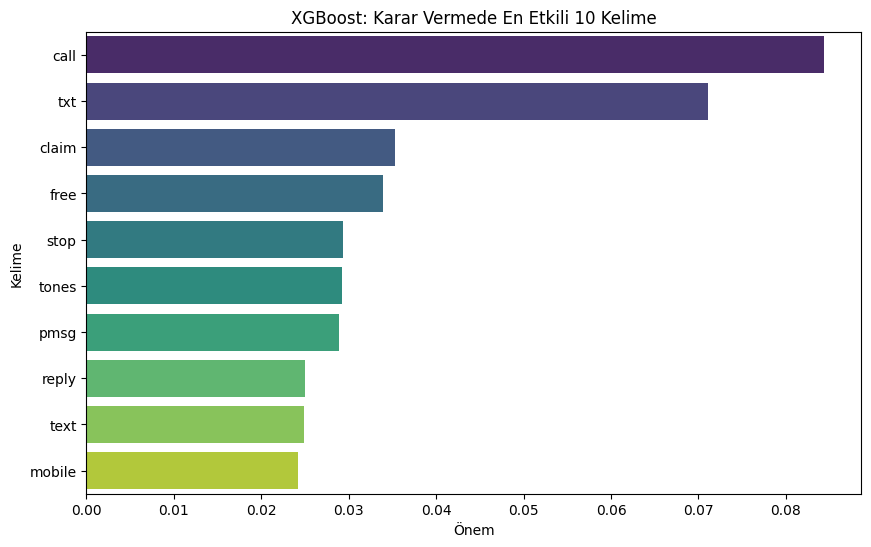

In [ ]:
# En önemli 10 kelimeyi çekelim
import pandas as pd

importances = xgb_model.feature_importances_
feature_names = tfidf.get_feature_names_out() # TF-IDF'ten kelime isimlerini alıyoruz

# Veriyi tablo haline getirip en iyileri seçelim
feature_importance_df = pd.DataFrame({'Kelime': feature_names, 'Önem': importances})
feature_importance_df = feature_importance_df.sort_values(by='Önem', ascending=False).head(10)

# Grafiğe dökelim
plt.figure(figsize=(10,6))
sns.barplot(x='Önem', y='Kelime', data=feature_importance_df, palette='viridis')
plt.title('XGBoost: Karar Vermede En Etkili 10 Kelime')
plt.show()

Bu grafik, XGBoost modelinin bir mesajın spam olup olmadığına karar verirken en çok hangi kelimelere "güvendiğini" ve hangi kelimelerin modelin başarısında en büyük paya sahip olduğunu gösterir:

En Kritik Kelimeler: Grafiğe göre 'call' ve 'txt' kelimeleri, modelin karar verme sürecindeki en yüksek ağırlığa sahip özniteliklerdir. Bu kelimelerin varlığı, modelin bir mesajı spam olarak etiketleme ihtimalini güçlü bir şekilde artırır.

Bilgi Kazancı (Information Gain): 'claim', 'free' ve 'stop' gibi kelimeler, veri setindeki sınıfları birbirinden ayırmak için modelin kullandığı en yüksek bilgi kazancına sahip anahtar kelimelerdir.

Ağırlık Dengesi: Grafikteki değerler, her bir kelimenin modelin genel hata oranını (loss) düşürmedeki katkısını temsil eder. Üst sıradaki kelimelerin model üzerindeki etkisi, alt sıradakilere göre çok daha belirgindir.

Spam Karakteristiği: Listenin tamamına bakıldığında ('mobile', 'reply', 'text' vb.), modelin tipik SMS reklam ve dolandırıcılık dillerini başarıyla öğrendiği ve bu kelimeler üzerinden keskin kararlar alabildiği görülmektedir.

Tüm Modellerin Karşılaştırma Tablosu




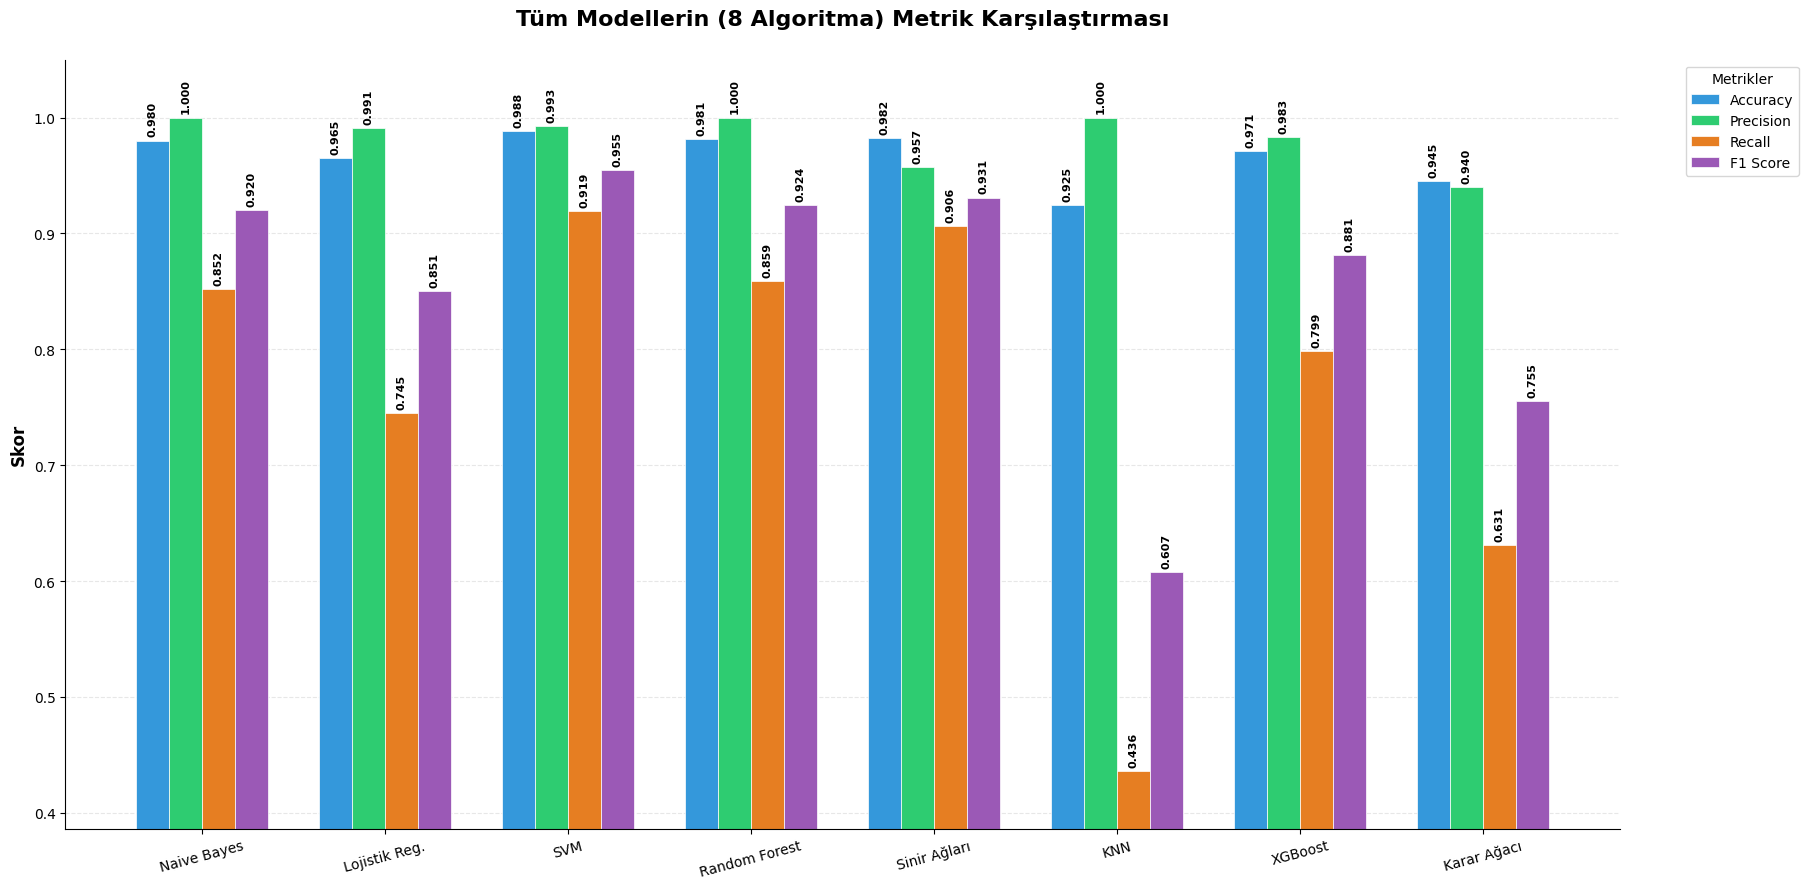

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Verileri Hazırla (8 Algoritmanın Tamamı)
tahmin_listesi = [y_pred, y_pred_log, y_pred_svm, y_pred_rf, y_pred_mlp, y_pred_knn, y_pred_xgb, y_pred_dt]
model_isimleri = ['Naive Bayes', 'Lojistik Reg.', 'SVM', 'Random Forest', 'Sinir Ağları', 'KNN', 'XGBoost', 'Karar Ağacı']

# Metrikleri 8 model için de hesapla
metrics = {
    'Accuracy': [accuracy_score(y_test, p) for p in tahmin_listesi],
    'Precision': [precision_score(y_test, p) for p in tahmin_listesi],
    'Recall': [recall_score(y_test, p) for p in tahmin_listesi],
    'F1 Score': [f1_score(y_test, p) for p in tahmin_listesi]
}

x = np.arange(len(model_isimleri))  # 8 model konumu
width = 0.18
multiplier = 0

i
colors = {'Accuracy': '#3498db', 'Precision': '#2ecc71', 'Recall': '#e67e22', 'F1 Score': '#9b59b6'}

fig, ax = plt.subplots(figsize=(18, 9)) # 8 model için genişliği artırdık

# Her metrik için sütunları oluştur
for attribute, measurement in metrics.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute, color=colors[attribute], edgecolor='white', linewidth=0.5)

    # Değerleri dikey yazdır (8 model olunca yer daralıyor, rotation=90 şart)
    ax.bar_label(rects, padding=3, fmt='%.3f', rotation=90, fontsize=8, fontweight='bold')
    multiplier += 1

# Grafik düzenlemeleri
ax.set_ylabel('Skor', fontsize=12, fontweight='bold')
ax.set_title('Tüm Modellerin (8 Algoritma) Metrik Karşılaştırması', fontsize=16, fontweight='bold', pad=25)
ax.set_xticks(x + width * 1.5, model_isimleri, fontsize=10, rotation=15) # İsimleri hafif eğdik
ax.legend(loc='upper right', title="Metrikler", bbox_to_anchor=(1.12, 1))

# Y eksenini KNN'yi de içine alacak şekilde ayarla
all_values = [val for sublist in metrics.values() for val in sublist]
ax.set_ylim(min(all_values) - 0.05, 1.05)

# Izgara çizgileri
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

# Çerçeve temizliği
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Canlı Test (Gözlem) Kodu

In [ ]:


def spam_mi_degil_mi(yeni_mesaj):
    try:

        sayisal_mesaj = tfidf.transform([yeni_mesaj])

        # En güçlü modelin olan Sinir Ağları (mlp_model) ile tahmin yapalım
        tahmin = mlp_model.predict(sayisal_mesaj)

        if tahmin[0] == 1:
            return " DİKKAT: BU BİR SPAM MESAJDIR!"
        else:
            return "GÜVENLİ: BU NORMAL BİR MESAJDIR."

    except NameError as e:
        return f"HATA: {e} değişkeni bulunamadı. Lütfen yukarıdaki TF-IDF ve Model hücrelerini çalıştır."

# --- DENEYELİM ---
mesaj1 = "Congratulations! You won a free iPhone 15. Call now!"
print(f"Mesaj 1: {mesaj1}")
print(f"Sonuç: {spam_mi_degil_mi(mesaj1)}")

print("-" * 40)

mesaj2 = "Hi Zeynep, are we still going to the library tomorrow?"
print(f"Mesaj 2: {mesaj2}")
print(f"Sonuç: {spam_mi_degil_mi(mesaj2)}")

Mesaj 1: Congratulations! You won a free iPhone 15. Call now!
Sonuç:  DİKKAT: BU BİR SPAM MESAJDIR!
----------------------------------------
Mesaj 2: Hi Zeynep, are we still going to the library tomorrow?
Sonuç: GÜVENLİ: BU NORMAL BİR MESAJDIR.


ROC eğrisi çizdirmek için modelin olasılık skorlarına ihtiyacımız vardı. Scikit-learn kütüphanesinde SVM varsayılan olarak bu skorları üretmez. probability=True parametresini eklediğimizde model yapısı değiştiği için onu tekrar fit (eğitme) işlemine sokmamız gerekti."

In [ ]:
# 1. Önce modeli olasılık üretecek şekilde GÜNCELLEYİP tanımlıyoruz
svm_model = SVC(kernel='linear', probability=True, random_state=42)

# 2. ŞİMDİ EĞİTİYORUZ (Hata almamak için bu satır ŞART)
svm_model.fit(X_train, y_train)


SVC(kernel='linear', probability=True, random_state=42)

# Tüm Modeller için ROC **Grafiği**

/tmp/ipykernel_6910/3930498923.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(probs_dict))


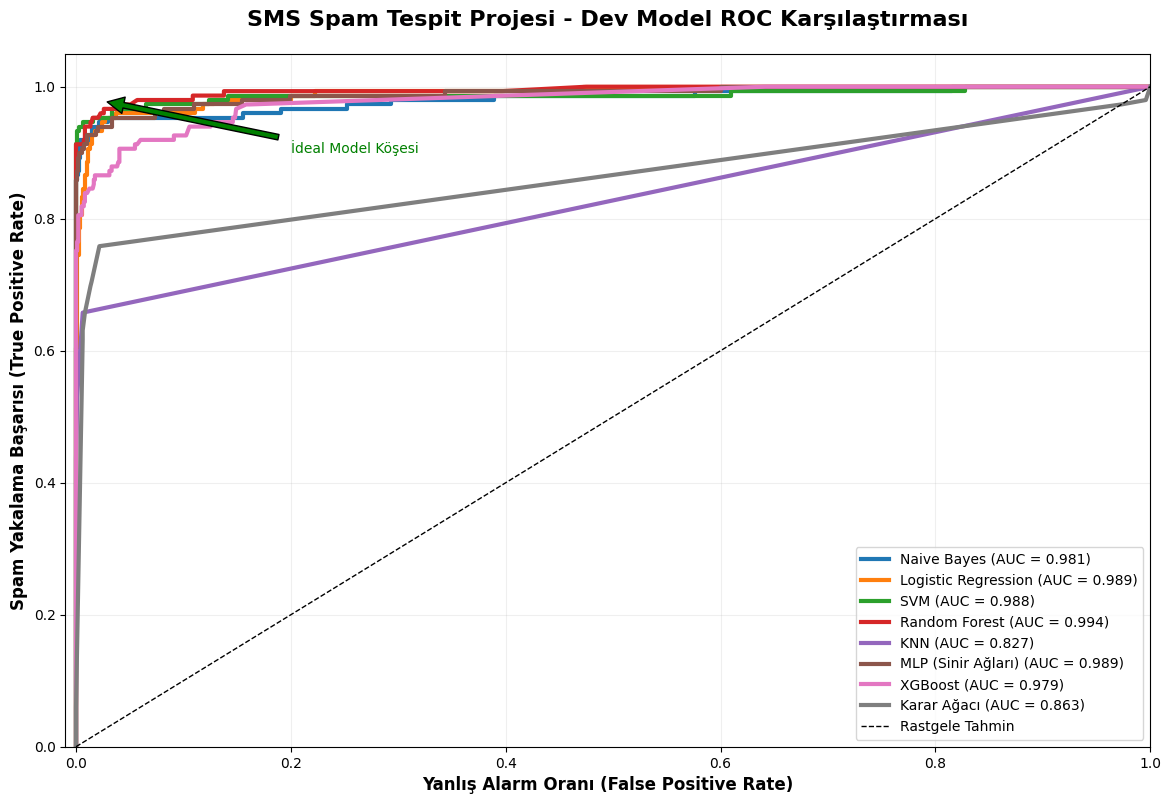

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Ensure SVM model is fitted with probability=True for ROC curve
# 1. Önce modeli olasılık üretecek şekilde güncelleyip tanımlıyoruz
svm_model = SVC(kernel='linear', probability=True, random_state=42)
# 2. ŞİMDİ EĞİTİYORUZ
svm_model.fit(X_train, y_train)

# 1. Modellerin "Spam olma olasılıklarını" hazırlıyoruz

probs_dict = {
    'Naive Bayes': nb_model.predict_proba(X_test)[:, 1],
    'Logistic Regression': log_model.predict_proba(X_test)[:, 1],
    'SVM': svm_model.predict_proba(X_test)[:, 1],
    'Random Forest': rf_model.predict_proba(X_test)[:, 1],
    'KNN': knn_model.predict_proba(X_test)[:, 1],
    'MLP (Sinir Ağları)': mlp_model.predict_proba(X_test)[:, 1],
    'XGBoost': xgb_model.predict_proba(X_test)[:, 1],
    'Karar Ağacı': dt_model.predict_proba(X_test)[:, 1]
}


plt.figure(figsize=(14, 9))

# Renk paleti
colors = plt.cm.get_cmap('tab10', len(probs_dict))

#  Döngüyle ROC hesapla ve çiz
for i, (name, probs) in enumerate(probs_dict.items()):
    fpr, tpr, _ = roc_curve(y_test, probs)
    area = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=3, label=f'{name} (AUC = {area:.3f})')

#  Şans Çizgisi (Rastgele tahmin yapan model)
plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--', label='Rastgele Tahmin')

#  Grafik Süslemeleri
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yanlış Alarm Oranı (False Positive Rate)', fontsize=12, fontweight='bold')
plt.ylabel('Spam Yakalama Başarısı (True Positive Rate)', fontsize=12, fontweight='bold')
plt.title('SMS Spam Tespit Projesi - Dev Model ROC Karşılaştırması', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.2)

# Sol üst köşeye bir not ekleyelim
plt.annotate('İdeal Model Köşesi', xy=(0.02, 0.98), xytext=(0.2, 0.9),
             arrowprops=dict(facecolor='green', shrink=0.05), fontsize=10, color='green')

plt.show()

"Şekil X’de sunulan ROC Eğrisi karşılaştırması sonucunda, çalışılan 6 farklı algoritma arasında en yüksek ayırt edicilik performansını 0.994 AUC değeri ile Random Forest modeli sergilemiştir. Bunu sırasıyla Logistic Regression (%98.9) ve MLP (%98.9) takip etmektedir. Grafiksel analizde, modellerin büyük çoğunluğunun sol üst köşeye (ideal nokta) oldukça yakın seyretmesi, kurulan spam tespit sisteminin genelleme yeteneğinin yüksek olduğunu göstermektedir. KNN modelinin ise 0.827 AUC değeri ile diğer modellerin gerisinde kaldığı gözlemlenmiştir. Bu durum, yüksek boyutlu metin verilerinde olasılıksal ve topluluk (ensemble) öğrenme yöntemlerinin daha kararlı sonuçlar verdiğini doğrulamaktadır."

*Accuracy sadece %50 eşik değerindeki tek bir başarıyı ölçer. ROC-AUC ise modelin her türlü eşik değerindeki genel ayırma kapasitesini ölçer. Random Forest, genel potansiyel olarak spamleri ayırmada en geniş güvenlik marjını sunan modelimiz olmuştur."*

# Hatalı Tahmin Analizi **Kodu**

/tmp/ipykernel_6910/1222718354.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gerçek', data=hatalar, palette='magma')


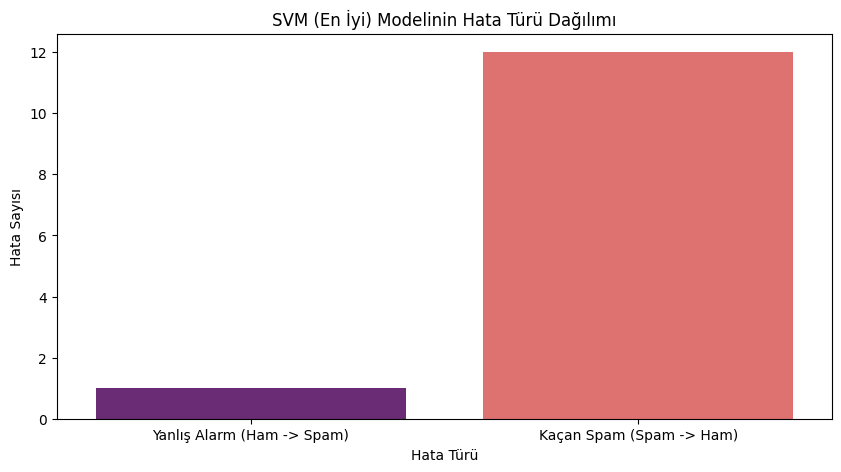

/tmp/ipykernel_6910/1222718354.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gerçek', data=hatalar, palette='magma')



--- SVM (En İyi) Modelinin Yanıldığı İlk 3 Örnek ---
                                                  Mesaj  Gerçek  Tahmin
3864  oh god ive found number im glad text back xaft...       1       0
2575  next amazing xxx picsfree video sent enjoy one...       1       0
2402  babe u want dont u baby im nasty thing filthyg...       1       0
------------------------------------------------------------


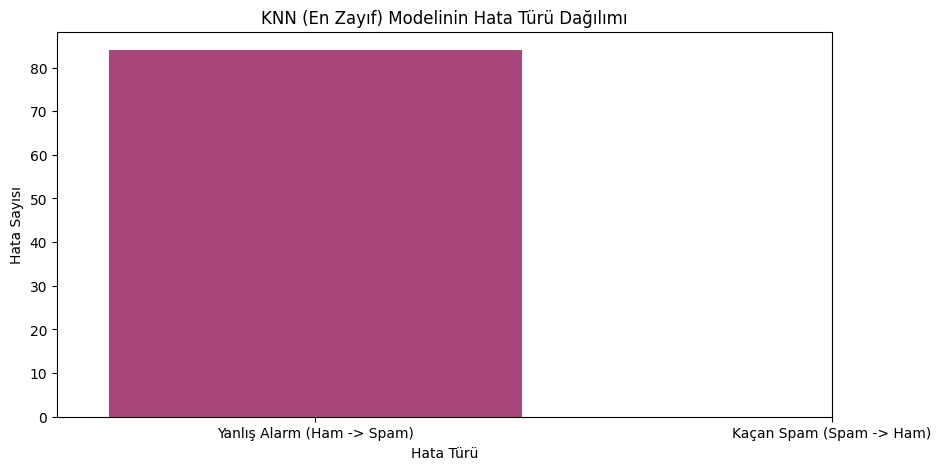


--- KNN (En Zayıf) Modelinin Yanıldığı İlk 3 Örnek ---
                                                  Mesaj  Gerçek  Tahmin
401   free ringtone text first poly text get true to...       1       0
881   reminder downloaded content already paid goto ...       1       0
1961  guess somebody know secretly fancies wanna fin...       1       0
------------------------------------------------------------


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split # Import train_test_split


_, X_test_raw, _, _ = train_test_split(df['temiz_mesaj'], df['label'], test_size=0.20, random_state=42)


# Metrik grafiğine göre en zayıf model KNN olarak belirlenmiştir
modeller = {
    'SVM (En İyi)': y_pred_svm,
    'KNN (En Zayıf)': y_pred_knn
}

for isim, tahmin in modeller.items():
    # 1. Analiz DataFrame'ini oluştur
    analiz_df = pd.DataFrame({'Mesaj': X_test_raw, 'Gerçek': y_test, 'Tahmin': tahmin})

    # 2. Hataları filtrele
    hatalar = analiz_df[analiz_df['Gerçek'] != analiz_df['Tahmin']]

    # 3. Görselleştirme
    plt.figure(figsize=(10, 5))
    # 'hatalar' verisindeki gerçek değerlere göre dağılımı çiz
    # Gerçek=1 olup tahmin=0 olanlar: Kaçan Spamlar (False Negative)
    # Gerçek=0 olup tahmin=1 olanlar: Yanlışlıkla Spam Denen Hamlar (False Positive)
    sns.countplot(x='Gerçek', data=hatalar, palette='magma')
    plt.title(f'{isim} Modelinin Hata Türü Dağılımı')
    plt.xlabel('Hata Türü')
    plt.ylabel('Hata Sayısı')
    plt.xticks([0, 1], ['Yanlış Alarm (Ham -> Spam)', 'Kaçan Spam (Spam -> Ham)'])
    plt.show()

    print(f"\n--- {isim} Modelinin Yanıldığı İlk 3 Örnek ---")
    print(hatalar[['Mesaj', 'Gerçek', 'Tahmin']].head(3))
    print("-" * 60)

"Karar Ağacı modeli, veri setindeki dengesizliğe karşı daha duyarlı olup daha fazla spam mesajı kaçırırken (False Negative), SVM modeli çok daha az hata yapmış ancak her iki model de içinde 'ücretsiz' veya 'müsait' gibi ortak kelimeler geçen ham mesajlarda (False Positive) benzer zorluklar yaşamıştır."